# Context Engineering for AI Agents: Memory vs. Compaction vs. Tool Clearing

## Introduction

A common challenge when building long-horizon agents is managing context. Tool results, the model's own reasoning, and user messages all accumulate, and eventually you either hit the token limit or start paying for context that isn't helping anymore. Studies on needle-in-a-haystack style benchmarking have uncovered the concept of [context rot](https://research.trychroma.com/context-rot): as the number of tokens in the context window increases, the model's ability to accurately recall information from that context decreases. So, even before the hard context limit is reached, the agent may be getting less out of each token.

Our engineering blog on [effective context engineering for AI agents](https://www.anthropic.com/engineering/effective-context-engineering-for-ai-agents) frames this as a resource problem: context is finite with diminishing marginal returns, and the core discipline is finding the smallest set of high-signal tokens that maximize the likelihood of your desired outcome. There are several levers for this: subagents that isolate work in their own context, programmatic tool calling that keeps large results out of the window entirely, and others.

This cookbook focuses on three: **compaction**, **tool-result clearing**, and **memory**. All three are effective strategies for context engineering, but since they all operate to make the context window more efficient in different ways, they can be hard to distinguish. Understanding those distinctions is what lets you map each tool to the part of your workload it actually helps with. Alongside other core context management strategies like utilizing subagents, these three are crucial for teams building long-running agents to understand. They also all have first-party API support, so you can adopt them without building orchestration infrastructure.

- **Compaction** distills the contents of a context window into a high-fidelity summary, letting the agent continue with minimal performance degradation when the conversation gets long.
- **Tool-result clearing** addresses the bloat from tool use itself. As an agent pulls in tools and calls them, the results pile up, and deciding how much of that tool output to keep becomes an increasingly important part of managing context. Clearing drops old, re-fetchable results while keeping the record that the call happened.
- **Memory** is structured note-taking: the agent writes to persistent external storage so it can track progress across tasks and sessions without keeping everything in active context.

[Claude Code](https://claude.com/product/claude-code) employs multiple of these strategies in production: compaction for long conversations and two complementary memory systems for cross-session persistence. Our API offers first-party implementations of all three: [server-side compaction](https://platform.claude.com/docs/en/build-with-claude/compaction), [context editing](https://platform.claude.com/docs/en/build-with-claude/context-editing) (which includes tool-result clearing), and the [memory tool](https://platform.claude.com/docs/en/agents-and-tools/tool-use/memory-tool). This cookbook works through how to think about designing with them: when each one applies, how to configure them, what changes when you use them independently vs. together, and sample use-cases where different combinations make sense.

The examples center on a **long-running research agent**: one that reads a corpus of documents, takes notes, and builds on its findings across multiple sessions. It's a useful test case because it naturally hits all three problems: bulky document reads (clearing), long analytical conversations (compaction), and knowledge that needs to survive between sessions (memory).

### What you'll learn

- How to **cap in-session token growth** with `clear_tool_uses` when an agent's context is dominated by large, re-fetchable tool results like file reads and API responses
- How to **keep long conversations going** with server-side compaction, including how to serialize the `compaction` block back and probe what survives the summary
- How to **persist agent knowledge across sessions** by implementing a file-backed memory handler that the model drives itself, so Session 2 picks up where Session 1 left off
- How to **implement each primitive most effectively**, replacing the default compaction prompt to preserve what your agent needs, guiding what the agent writes to `/memories`, and testing clearing configs against your own workload's tool-use pattern
- How to **diagnose which part of the context problem your workload actually has**, and pick the primitive that targets it, with a framework for mapping workload characteristics to the right tool

### Prerequisites

To run this notebook, you will need:

- **Anthropic API key** set as `ANTHROPIC_API_KEY` in your environment or a `.env` file ([get one here](https://platform.claude.com/))
- **Python 3.11+** with the `anthropic`, `python-dotenv`, and `matplotlib` packages installed
- **`research_corpus.py`** alongside this notebook (included in the repository). It defines `CORPUS`, a dict of eight synthetic review documents on model organisms for aging research (~40K tokens each, ~320K tokens total), plus probe questions used later to test what survives compaction. You can swap in your own documents by replacing the dict.

> **Running from the cookbooks repo?** Ensure your working directory is `tool_use/context_engineering` before running the notebook.

## Step 0: Environment Setup

Create a `.env` file in this directory with your Anthropic API key:

```
ANTHROPIC_API_KEY=your-key-here
```

In [1]:
%%capture
%pip install anthropic python-dotenv matplotlib

In [2]:
import json
import os
import tempfile
from collections import namedtuple
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("ANTHROPIC_API_KEY"):
    raise ValueError("ANTHROPIC_API_KEY not set. Add it to a .env file or export it.")

CORPUS_PATH = Path("research_corpus.py")
assert CORPUS_PATH.exists(), (
    f"research_corpus.py not found in {Path.cwd()}. It should be alongside this notebook."
)

client = anthropic.Anthropic()
MODEL = "claude-sonnet-4-6"
print(f"anthropic SDK {anthropic.__version__}, model {MODEL}")

anthropic SDK 0.84.0, model claude-sonnet-4-6


In [3]:
# Force-reload the corpus module in case this kernel has a stale cached version
import importlib

import research_corpus

importlib.reload(research_corpus)
from research_corpus import COMPACTION_PROBES, CORPUS

# Count tokens via the API (cached in-memory so repeat kernel runs are fast).
_token_cache: dict[str, int] = {}


def count_tokens(text: str) -> int:
    if text not in _token_cache:
        _token_cache[text] = client.messages.count_tokens(
            model=MODEL, messages=[{"role": "user", "content": text}]
        ).input_tokens
    return _token_cache[text]


print(f"CORPUS is a dict of {len(CORPUS)} synthetic documents held in Python memory.")
print("When the agent calls read_file, the content is served from this dict and")
print("lands directly in the agent's context window — no disk I/O involved.\n")
_total_tokens = 0
for path, content in CORPUS.items():
    n_tok = count_tokens(content)
    _total_tokens += n_tok
    # Strip the virtual directory prefix for display clarity
    display_name = path.removeprefix("/research/")
    print(f"  {display_name:<26} ~{n_tok:>6,} tokens")
print(f"\n  Total corpus: ~{_total_tokens:,} tokens")

# Sanity check: the corpus should be large enough to push context well past
# 200K in a single read-pass. If this fires, research_corpus.py may be stale.
assert _total_tokens > 250_000, (
    f"Corpus is only {_total_tokens:,} tokens; expected >250K. "
    "Restart the kernel and re-run, or verify research_corpus.py is current."
)

CORPUS is a dict of 8 synthetic documents held in Python memory.
When the agent calls read_file, the content is served from this dict and
lands directly in the agent's context window — no disk I/O involved.

  celegans_review.md         ~41,260 tokens
  drosophila_review.md       ~41,200 tokens
  mouse_review.md            ~41,155 tokens
  zebrafish_review.md        ~41,095 tokens
  killifish_review.md        ~41,115 tokens
  yeast_review.md            ~41,101 tokens
  nmr_review.md              ~41,017 tokens
  rhesus_review.md           ~41,012 tokens

  Total corpus: ~328,955 tokens


## The Problem: A Long-Running Research Agent

The agent in this cookbook plays the role of a biology researcher writing a comparative review of model organisms for aging and longevity research. The task is realistic enough to matter: it involves reading through a corpus of review documents (one per organism), extracting comparable facts (lifespan, genetic tractability, translational relevance), taking structured notes, and synthesizing findings across everything read.

This kind of work is where context management starts to bite. Each document is around 40K tokens (narrative plus extensive appendix tables of intervention data), and the task asks the agent to read them in two batches: four high-throughput organisms (C. elegans, Drosophila, yeast, killifish) first, then four low-throughput organisms (mouse, zebrafish, naked mole-rat, rhesus). The two-batch structure is an experimental design choice for this cookbook: it produces a context trajectory that climbs past the compaction trigger on the first batch and past the 200K reference line on the second, so each primitive's effect on the trajectory is visible in the same run. Without context management, the agent's context grows to hundreds of thousands of tokens mid-task. And since the work spans sessions, even a completed run starts the next session with no memory of what was learned.

### The research task

The agent's concrete assignment: compare the model organisms in `/research/` on three dimensions (lifespan and experimental throughput, genetic tractability, and translational relevance to human aging), reading the eight review documents in two batches and taking notes as it goes, then writing a comparative synthesis.

## How the Three APIs Map to the Problem

Each API targets a different kind of context growth. Understanding which kind you're facing is the first step to picking the right tool.

### Conceptually

**Compaction** is the practice of taking a conversation nearing the context window limit, summarizing its contents, and reinitiating with that summary. It aims to distill the context window in a high-fidelity manner so the agent can continue with minimal performance degradation. The art of compaction lies in what to keep versus what to discard: overly aggressive compaction can lose subtle but critical context whose importance only becomes apparent later. The summary preserves architectural decisions, unresolved questions, and key facts while discarding redundant content; it's lossy by design, but handles all context growth, not just tool results. Compaction is a *whole-transcript* operation: user messages, assistant messages, tool calls, tool results, even prior compaction blocks are all flattened into the summary.

**Tool-result clearing**, by contrast, is a *sub-transcript* operation. It walks the message list and surgically replaces `tool_result` content blocks, leaving everything else — user messages, assistant reasoning, the `tool_use` record — untouched. When an agent calls tools, the results become part of the conversation history and count against the context budget on every subsequent turn. Much of that content is re-fetchable: file contents the agent can re-read, API responses it can re-request. Clearing replaces old `tool_result` blocks with a short placeholder, keeping the `tool_use` record so the model still knows it made the call, but dropping the bulky payload. Once a tool has been called deep in the message history, the agent rarely needs to see the raw result again; clearing is one of the safest, lightest-touch ways to recover that space. If the agent does need the data, it just calls the tool again.

**Memory**, or structured note-taking, is a technique where the agent regularly writes notes persisted outside the context window, then pulls them back in at later times. This provides persistent memory with minimal overhead: the agent tracks progress across complex tasks, maintaining critical context that would otherwise be lost across dozens of tool calls or across context resets. After a reset (a new session, or after compaction), the agent reads its own notes and continues. You implement the storage backend, so you control what's stored and for how long.

Beyond enabling these primitives, it's also important to understand how to implement them most effectively: the default behavior gets you started, but the quality of a compaction summary and the usefulness of what lands in memory both depend on guidance you provide. Each primitive's section below includes a subsection on effective implementation.

### Tactically

| API | Identifier | Beta header | Triggered by | Configurable knobs |
|---|---|---|---|---|
| Compaction | `compact_20260112` | `compact-2026-01-12` | Token threshold (server-side, min 50K) | `trigger` (default 150K), `instructions`, `pause_after_compaction` |
| Tool clearing | `clear_tool_uses_20250919` | `context-management-2025-06-27` | Token threshold (server-side) | `trigger` (default 100K), `keep` (default 3 tool uses), `clear_at_least`, `exclude_tools`, `clear_tool_inputs` |
| Memory tool | `memory_20250818` | none (standalone) | The model (it's a tool call) | Client implements: `view`, `create`, `str_replace`, `insert`, `delete`, `rename` |

### Mapped to the research agent

For the research agent specifically, the three problems line up cleanly:

- The agent's running commentary ("C. elegans is 18-day lifespan with genome-wide RNAi, mouse is 30 months but costs $100K per cohort...") and the user's follow-up questions accumulate into a long dialogue. That's a **compaction** problem.
- Reading eight ~40K-token review documents produces roughly 320K tokens of tool-result volume, significantly into the range where model performance decays from context rot. Most of it the agent could re-read on demand. That's a **clearing** problem.
- The work spans multiple sessions. If Session 1 determined that killifish is the shortest-lived vertebrate (4-6 months), we want Session 2 to retain that finding and build on it rather than rediscover it from scratch. That's a **memory** problem.

A rough mental model for prioritizing: compaction compresses the whole window when it grows too large, clearing drops stale re-fetchable data inside the window, and memory moves information out of the window so it survives across sessions. Each layer adds config to tune and interactions to understand, so it's worth starting with the one that matches the bottleneck you're actually observing.

## The Research Agent

Before exploring each primitive, we set up the agent itself: tool schemas, tool execution, and an agent loop that can be run with or without any context-management configuration. Everything is inline so you can see the full loop.

In [4]:
# ── Tool schemas ─────────────────────────────────────────────────────────
RESEARCH_TASK = """Compare the model organisms in /research/ on three dimensions:
1. Lifespan and experimental throughput (how fast can you get a lifespan result?)
2. Genetic tractability (what tools exist for manipulation and screening?)
3. Translational relevance (how well do findings transfer to human aging?)

Work through the organisms in two batches, recording a note after each
batch before moving on:

BATCH 1 (high-throughput models): Read celegans_review.md,
drosophila_review.md, yeast_review.md, and killifish_review.md. Record a
single detailed note covering all four organisms on all three dimensions.
Do not begin Batch 2 until this note is recorded.

BATCH 2 (low-throughput models): Read mouse_review.md,
zebrafish_review.md, nmr_review.md, and rhesus_review.md. Record a
single detailed note covering all four organisms on all three
dimensions.

After both batches, write a comprehensive comparative synthesis
contrasting the high-throughput and low-throughput models."""

BASE_TOOLS: list[dict] = [
    {
        "name": "search_files",
        "description": "Search document filenames and contents for a keyword. Returns matching paths with a short excerpt.",
        "input_schema": {
            "type": "object",
            "properties": {"query": {"type": "string", "description": "Search term"}},
            "required": ["query"],
        },
    },
    {
        "name": "read_file",
        "description": "Read the full content of a document by path.",
        "input_schema": {
            "type": "object",
            "properties": {
                "path": {"type": "string", "description": "e.g. /research/celegans_review.md"}
            },
            "required": ["path"],
        },
    },
    {
        "name": "record_finding",
        "description": "Record a research finding (freeform text). Findings are held for the duration of this session only; they are not persisted across sessions.",
        "input_schema": {
            "type": "object",
            "properties": {"finding": {"type": "string"}},
            "required": ["finding"],
        },
    },
]

# The memory tool spec is defined here but only added to the agent's tool
# list when a memory_handler is passed to run_research_session. Baseline
# and clearing/compaction runs do NOT get the memory tool.
MEMORY_TOOL_SPEC = {"type": "memory_20250818", "name": "memory"}

SYSTEM_PROMPT = """You are a biology research analyst writing a comparative review of model organisms for aging research.

Work systematically: search and read review documents, take notes on key facts (lifespans, genetic tools, translational strengths and caveats), and build a comparative picture.

Be concise in your reasoning text; the goal is notes, not essays."""

In [5]:
# ── Tool execution ───────────────────────────────────────────────────────
def execute_research_tool(name: str, tool_input: dict, notes: list[str]) -> str:
    if name == "search_files":
        query = tool_input.get("query", "").lower()
        if not query:
            return "Error: query is required."
        hits: list[str] = []
        for path, content in CORPUS.items():
            if query in path.lower() or query in content.lower():
                for line in content.split("\n"):
                    if query in line.lower():
                        hits.append(f"  {path}\n    → {line.strip()[:120]}")
                        break
                else:
                    hits.append(f"  {path}")
        return (
            f"Found {len(hits)} match(es):\n" + "\n".join(hits)
            if hits
            else f"No matches for '{query}'."
        )

    if name == "read_file":
        path = tool_input.get("path", "")
        content = CORPUS.get(path)
        if content is None:
            return f"Error: '{path}' not found. Available: {', '.join(CORPUS.keys())}"
        return content

    if name == "record_finding":
        finding = tool_input.get("finding", "")
        notes.append(finding)
        return f"Finding #{len(notes)} recorded (session-local)."

    return f"Error: unknown tool '{name}'"

In [6]:
# ── Session result container ─────────────────────────────────────────────
SessionResult = namedtuple(
    "SessionResult",
    [
        "messages",  # final message list
        "notes",  # notes taken this session
        "token_trajectory",  # list of (turn, total_context_tokens)
        "events",  # list of dicts describing compaction / clearing events
        "tool_counts",  # dict of tool_name -> call count
        "file_reads",  # list of (turn, path) for each read_file call
        "hit_limit",  # True if the session stopped because it hit the context window
        "final_text",  # final assistant text (convenience)
    ],
)


def _format_tool_arg(name: str, tool_input: dict) -> str:
    """Human-readable one-line summary of a tool call's arguments for verbose output."""
    if name == "search_files":
        return repr(tool_input.get("query", ""))
    if name == "read_file":
        return tool_input.get("path", "?")
    if name == "record_finding":
        finding = tool_input.get("finding", "")
        preview = finding[:50].replace("\n", " ")
        return f'"{preview}{"..." if len(finding) > 50 else ""}"'
    if name == "memory":
        cmd = tool_input.get("command", "?")
        path = tool_input.get("path", tool_input.get("old_path", ""))
        return f"{cmd} {path}"
    return str(tool_input)[:60]


# ── Agent loop ───────────────────────────────────────────────────────────
def run_research_session(
    initial_prompt: str,
    *,
    context_management: dict | None = None,
    betas: list[str] | None = None,
    memory_handler=None,
    max_turns: int = 12,
    label: str = "session",
    verbose: bool = True,
) -> SessionResult:
    """Run the research agent. Catches context-window overflow gracefully."""
    tools = list(BASE_TOOLS)
    if memory_handler is not None:
        tools.append(MEMORY_TOOL_SPEC)

    messages: list[dict] = [{"role": "user", "content": initial_prompt}]
    notes: list[str] = []
    token_trajectory: list[tuple[int, int]] = []
    events: list[dict] = []
    tool_counts: dict[str, int] = {}
    file_reads: list[tuple[int, str]] = []  # (turn, path) for each read_file
    hit_limit = False
    final_text = ""

    if verbose:
        print(f"┌─ [{label}]")

    for turn in range(1, max_turns + 1):
        kwargs: dict = dict(
            model=MODEL,
            max_tokens=4096,
            system=SYSTEM_PROMPT,
            tools=tools,
            messages=messages,
        )
        if context_management:
            kwargs["context_management"] = context_management
        if betas:
            kwargs["betas"] = betas

        # Call the API; catch context-window overflow
        try:
            if betas:
                response = client.beta.messages.create(**kwargs)
            else:
                response = client.messages.create(**kwargs)
        except anthropic.BadRequestError as e:
            # Context window exceeded (or similar input-too-large error)
            hit_limit = True
            if verbose:
                print(f"│  ⚠ CONTEXT WINDOW LIMIT REACHED at turn {turn} (API rejected)")
                print(f"│    {str(e)[:200]}")
            break

        # Track TOTAL context size: uncached + cache-read + cache-created.
        # usage.input_tokens alone excludes cached tokens, which makes the
        # plot show dips that are just cache hits, not context management.
        u = response.usage
        total_in = (
            u.input_tokens
            + (getattr(u, "cache_read_input_tokens", None) or 0)
            + (getattr(u, "cache_creation_input_tokens", None) or 0)
        )
        token_trajectory.append((turn, total_in))

        # Surface context-management events on their own prominent lines
        cm = getattr(response, "context_management", None)
        if cm is not None and getattr(cm, "applied_edits", None):
            for edit in cm.applied_edits:
                cleared_uses = getattr(edit, "cleared_tool_uses", None)
                cleared_toks = getattr(edit, "cleared_input_tokens", None)
                events.append(
                    {
                        "turn": turn,
                        "kind": "clearing",
                        "cleared_tool_uses": cleared_uses,
                        "cleared_input_tokens": cleared_toks,
                    }
                )
                if verbose:
                    print(
                        f"│  ✂ CLEARING (turn {turn}): {cleared_uses or '?'} tool results cleared, "
                        f"~{cleared_toks:,} tokens freed"
                        if cleared_toks
                        else f"│  ✂ CLEARING (turn {turn}): applied"
                    )

        # Serialize assistant content, track tool calls and compaction
        serialized: list[dict] = []
        tool_calls: list[dict] = []
        turn_tool_calls: list[tuple[str, dict]] = []  # (name, input) for verbose display
        compaction_this_turn = False
        for block in response.content:
            if block.type == "text":
                serialized.append({"type": "text", "text": block.text})
                if block.text.strip():
                    final_text = block.text
            elif block.type == "tool_use":
                serialized.append(
                    {
                        "type": "tool_use",
                        "id": block.id,
                        "name": block.name,
                        "input": block.input,
                    }
                )
                tool_calls.append({"id": block.id, "name": block.name, "input": block.input})
                turn_tool_calls.append((block.name, block.input))
                tool_counts[block.name] = tool_counts.get(block.name, 0) + 1
                # Track file reads specifically so we can show what clearing drops
                if block.name == "read_file":
                    file_reads.append((turn, block.input.get("path", "?")))
            elif block.type == "thinking":
                serialized.append(
                    {"type": "thinking", "thinking": block.thinking, "signature": block.signature}
                )
            elif block.type == "compaction":
                serialized.append({"type": "compaction", "content": block.content})
                events.append({"turn": turn, "kind": "compaction", "summary": block.content})
                compaction_this_turn = True
                if verbose:
                    print(
                        f"│  ⊟ COMPACTION (turn {turn}): "
                        f"~{count_tokens(block.content):,}-token summary replaces prior turns"
                    )
        messages.append({"role": "assistant", "content": serialized})

        if not tool_calls:
            if verbose and not compaction_this_turn:
                print(f"│  turn {turn:2d}  ctx={total_in:>7,}  (final answer)")
            break

        # Execute tools, collecting result sizes so the verbose print
        # can show how much each call added to context
        tool_results: list[dict] = []
        result_sizes: list[int] = []
        for call in tool_calls:
            if call["name"] == "memory" and memory_handler is not None:
                result = memory_handler.handle(call["input"])
            else:
                result = execute_research_tool(call["name"], call["input"], notes)
            tool_results.append(
                {
                    "type": "tool_result",
                    "tool_use_id": call["id"],
                    "content": result,
                }
            )
            result_sizes.append(len(result) if isinstance(result, str) else 0)
        messages.append({"role": "user", "content": tool_results})

        if verbose and not compaction_this_turn:
            # Header with context size, then one line per tool call with
            # its argument and approximate result size (so you can see
            # which calls are responsible for the next turn's ctx jump)
            print(f"│  turn {turn:2d}  ctx={total_in:>7,}")
            for (name, tinput), rsize in zip(turn_tool_calls, result_sizes, strict=False):
                size_note = f"  → ~{rsize // 4:,} tok" if rsize > 200 else ""
                print(f"│            {name:<16} {_format_tool_arg(name, tinput)}{size_note}")

    if verbose:
        if token_trajectory:
            peak = max(t for _, t in token_trajectory)
            status = "⚠ HIT CONTEXT LIMIT" if hit_limit else "completed"
            print(
                f"└─ {status}: {len(token_trajectory)} turns, peak ctx {peak:,}, "
                f"final ctx {token_trajectory[-1][1]:,}, {len(events)} context event(s)\n"
            )
        else:
            print("└─ HIT CONTEXT LIMIT on first turn: 0 turns completed\n")

    return SessionResult(
        messages, notes, token_trajectory, events, tool_counts, file_reads, hit_limit, final_text
    )


def show_cleared_reads(result: SessionResult, keep: int):
    """Show which file reads are no longer in context after clearing.

    Clearing replaces tool results older than the last `keep` tool uses
    with placeholders. We reconstruct the tool-use order and mark any
    read that falls outside the surviving `keep`-window as cleared.

    Note: if clearing fires multiple times, only the last event's
    boundary is considered and earlier cleared-then-re-read files may
    be misclassified.
    """
    if not result.file_reads:
        print("No file reads in this session.")
        return
    clearing_events = [e for e in result.events if e["kind"] == "clearing"]
    if not clearing_events:
        print("Clearing never fired; all file reads remain in context.")
        return

    # Walk messages in order to reconstruct the sequence of tool_use blocks
    # and which turn each one came from. The last `keep` of these survive
    # the most recent clearing; earlier ones are cleared.
    tool_use_seq: list[tuple[int, str, str]] = []  # (turn, name, path-if-read)
    turn = 0
    for msg in result.messages:
        if msg["role"] == "assistant" and isinstance(msg["content"], list):
            turn += 1
            for block in msg["content"]:
                if block.get("type") == "tool_use":
                    name = block.get("name", "?")
                    path = block.get("input", {}).get("path", "") if name == "read_file" else ""
                    tool_use_seq.append((turn, name, path))

    last_clear_turn = clearing_events[-1]["turn"]
    seq_before = [t for t in tool_use_seq if t[0] < last_clear_turn]
    cleared_reads = [(t, p) for (t, n, p) in seq_before[:-keep] if n == "read_file"]
    surviving_reads = [
        (t, p) for tu in seq_before[-keep:] for (t, n, p) in [tu] if n == "read_file"
    ]
    # Reads at or after the last clearing turn are untouched by it.
    surviving_reads += [
        (t, p) for (t, n, p) in tool_use_seq if t >= last_clear_turn and n == "read_file"
    ]

    total = len(result.file_reads)
    print(f"Total file reads across session: {total}")
    print(f"Last clearing event fired at turn {last_clear_turn} (keep={keep})")
    print(f"\nReads cleared from context: {len(cleared_reads)}")
    for turn, path in cleared_reads[:12]:
        print(f"  ✗ turn {turn:2d}: {path}")
    if len(cleared_reads) > 12:
        print(f"  ... and {len(cleared_reads) - 12} more")
    print(
        f"\nReads still in context (within the keep={keep} window or after "
        f"the last clearing): {len(surviving_reads)}"
    )
    for turn, path in surviving_reads[:6]:
        print(f"  ✓ turn {turn:2d}: {path}")
    if len(surviving_reads) > 6:
        print(f"  ... and {len(surviving_reads) - 6} more")


# ── Plot helpers ─────────────────────────────────────────────────────────


def plot_trajectories(
    results: dict[str, SessionResult],
    title: str = "Context size per turn",
    triggers: dict[str, int] | None = None,
    project_growth_for: str | None = None,
):
    """Line plot of context tokens per turn.

    Vertical dashed lines mark turns where clearing fired; dash-dot lines
    mark compaction. Horizontal dotted lines mark configured trigger
    thresholds (pass triggers={"clearing": 20000, "compaction": 50000} etc).

    project_growth_for: label of a run to extrapolate. Fits a line to the
    last 5 points and draws a dotted segment forward ~8 turns to show where
    unmanaged growth is heading.
    """
    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (label, res) in enumerate(results.items()):
        turns = [t for t, _ in res.token_trajectory]
        tokens = [tok for _, tok in res.token_trajectory]
        color = colors[i % len(colors)]
        ax.plot(turns, tokens, marker="o", label=label, markersize=4, color=color)
        # Mark events on the x-axis
        for ev in res.events:
            style = "--" if ev["kind"] == "clearing" else "-."
            ax.axvline(x=ev["turn"], color=color, linestyle=style, alpha=0.25, linewidth=1)
        # Dotted growth projection for the named run, capped at 1M
        if label == project_growth_for and len(turns) >= 3:
            HARD_LIMIT = 1_000_000
            fit_n = min(5, len(turns))
            xs, ys = turns[-fit_n:], tokens[-fit_n:]
            n = len(xs)
            sx, sy = sum(xs), sum(ys)
            slope = (n * sum(x * y for x, y in zip(xs, ys, strict=False)) - sx * sy) / (
                n * sum(x * x for x in xs) - sx * sx
            )
            intercept = (sy - slope * sx) / n
            proj_x, proj_y = [], []
            for x in range(turns[-1], turns[-1] + 9):
                y = slope * x + intercept
                if y > HARD_LIMIT:
                    # Clip the last segment to the 1M ceiling and stop
                    if proj_y and slope > 0:
                        proj_x.append(proj_x[-1] + (HARD_LIMIT - proj_y[-1]) / slope)
                        proj_y.append(HARD_LIMIT)
                    break
                proj_x.append(x)
                proj_y.append(y)
            if proj_y:
                ax.plot(proj_x, proj_y, linestyle=":", color=color, alpha=0.6, linewidth=1.5)

    # Horizontal reference lines for trigger thresholds
    if triggers:
        for name, value in triggers.items():
            ax.axhline(y=value, color="gray", linestyle=":", alpha=0.6, linewidth=1)
            ax.annotate(
                f"{name} trigger: {value:,}",
                xy=(ax.get_xlim()[1], value),
                xytext=(-5, 3),
                textcoords="offset points",
                ha="right",
                va="bottom",
                fontsize=8,
                color="gray",
            )

    # 200K reference: earlier models cap here and would hard-stop
    if ax.get_ylim()[1] > 30_000:
        ax.axhline(y=200_000, color="gray", linestyle="--", alpha=0.5, linewidth=1)
        ax.annotate(
            "200K: earlier models stop here",
            xy=(ax.get_xlim()[0], 200_000),
            xytext=(5, -12),
            textcoords="offset points",
            ha="left",
            va="top",
            fontsize=8,
            color="gray",
            alpha=0.8,
        )

    ax.set_xlabel("Turn")
    ax.set_ylabel("Context tokens (incl. cached)")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_summary_bars(results: dict[str, SessionResult], title: str = "Session outcomes"):
    """Side-by-side bars: final context, file reads."""
    labels = list(results.keys())
    final_ctx = [r.token_trajectory[-1][1] for r in results.values()]
    reads = [r.tool_counts.get("read_file", 0) for r in results.values()]

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    fig.suptitle(title, y=1.02)

    for ax, values, ylabel in zip(
        axes,
        [final_ctx, reads],
        ["Final context (tokens)", "File reads"],
        strict=False,
    ):
        bars = ax.bar(range(len(labels)), values, color=plt.cm.Set2(range(len(labels))))
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, values, strict=False):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:,}" if val > 1000 else str(val),
                ha="center",
                va="bottom",
                fontsize=7,
            )

    plt.tight_layout()
    plt.show()

### Baseline: no context management

First we run the agent with no context-management configuration. With the large corpus (each document is ~40K tokens with its appendix tables), context accumulates fast. We'll look at the same run under two lenses: what happens on a 1M-token window, and what would happen on a 200K window.

#### Part 1: On a 1M-token window

Claude Sonnet 4.6 and Claude Opus 4.6 both provide a [1M-token context window](https://platform.claude.com/docs/en/build-with-claude/context-windows). For this task, the baseline's total input stays under that limit: the agent reads the full corpus and synthesizes without hitting a hard wall. The trajectory below shows the run climbing to hundreds of thousands of tokens, with the dotted line projecting continued growth at the same rate.

┌─ [baseline]
│  turn  1  ctx=  1,058
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file        /research/yeast_review.md  → ~27,320 tok
│            read_file        /research/killifish_review.md  → ~27,349 tok
│  turn  2  ctx=166,043
│            record_finding   "## BATCH 1 NOTES: High-Throughput Model Organisms ..."
│  turn  3  ctx=168,242
│            read_file        /research/mouse_review.md  → ~27,390 tok
│            read_file        /research/zebrafish_review.md  → ~27,363 tok
│            read_file        /research/nmr_review.md  → ~27,287 tok
│            read_file        /research/rhesus_review.md  → ~27,285 tok
│  turn  4  ctx=332,821
│            record_finding   "## BATCH 2 NOTES: Low-Throughput Model Organisms —..."
│  turn  5  ctx=335,279  (final answer)
└─ completed: 5 turns, peak ctx 335,279, final ctx 335,279, 0 context event(s)



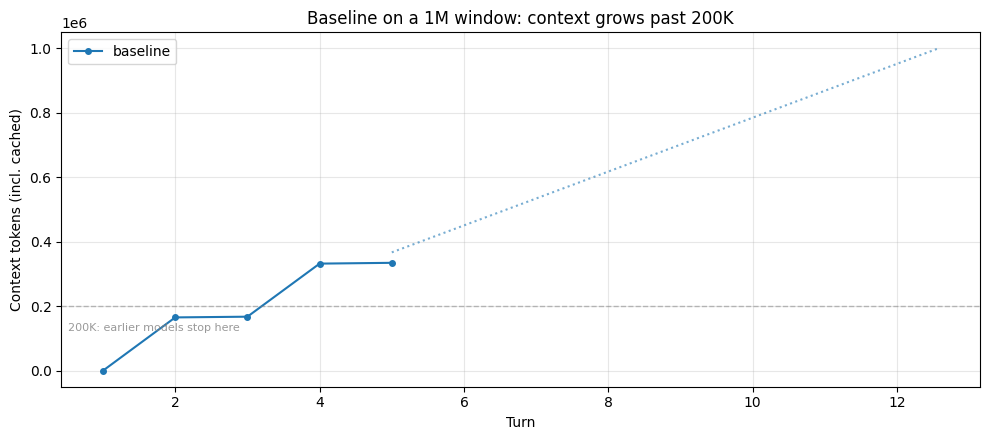

Peak context: 335,279 tokens across 5 turns
File reads: 8, Notes: 2

The run stayed within the 1M window. The dotted line projects where continued growth at the same rate would land, capped at 1M.


In [7]:
baseline = run_research_session(RESEARCH_TASK, label="baseline", max_turns=12)

plot_trajectories(
    {"baseline": baseline},
    "Baseline on a 1M window: context grows past 200K",
    project_growth_for="baseline",
)

peak = max(t for _, t in baseline.token_trajectory)
n_turns = len(baseline.token_trajectory)
print(f"Peak context: {peak:,} tokens across {n_turns} turns")
print(f"File reads: {baseline.tool_counts.get('read_file', 0)}, Notes: {len(baseline.notes)}")
if baseline.hit_limit:
    print("\n⚠ This run hit the 1M hard limit.")
else:
    print(
        "\nThe run stayed within the 1M window. The dotted line projects "
        "where continued growth at the same rate would land, capped at 1M."
    )

In [8]:
# ── What's actually sitting in the context window at the end of the run ──
# Walk the message list and bucket everything by type. This is what the
# model has to attend to on every turn: no hard wall stopped it, but the
# pile keeps growing and every fact from early turns is buried deeper.


def _bucket_context(messages: list[dict]) -> dict[str, tuple[int, int]]:
    """Categorize message content into (count, approx_tokens) per bucket."""
    buckets: dict[str, list[int]] = {
        "File-read results": [],
        "Other tool results": [],
        "Agent reasoning text": [],
        "Tool-call records": [],
        "User/task prompts": [],
    }
    for msg in messages:
        content = msg.get("content")
        if isinstance(content, str):
            buckets["User/task prompts"].append(len(content))
        elif isinstance(content, list):
            for block in content:
                bt = block.get("type")
                if bt == "tool_result":
                    body = block.get("content", "")
                    body = body if isinstance(body, str) else json.dumps(body)
                    # Heuristic: large tool results are file reads
                    key = "File-read results" if len(body) > 5000 else "Other tool results"
                    buckets[key].append(len(body))
                elif bt == "text":
                    buckets["Agent reasoning text"].append(len(block.get("text", "")))
                elif bt == "tool_use":
                    buckets["Tool-call records"].append(len(json.dumps(block.get("input", {}))))
    # chars // 4 as a rough token estimate; the exact number isn't the point
    return {k: (len(v), sum(v) // 4) for k, v in buckets.items() if v}


print("=" * 72)
print("WHAT THE MODEL IS ATTENDING TO at the end of the baseline run")
print("=" * 72)
breakdown = _bucket_context(baseline.messages)
total_est = sum(tok for _, tok in breakdown.values())
# Scale the char-based estimates so the total matches the API's reported
# context size. This keeps the proportions meaningful and the absolute
# numbers consistent with the usage figures shown elsewhere.
api_total = baseline.token_trajectory[-1][1]
scale = api_total / total_est if total_est else 1.0
print(f"\nContext breakdown ({api_total:,} tokens total per API usage):\n")
for label, (count, tokens) in sorted(breakdown.items(), key=lambda kv: -kv[1][1]):
    scaled = int(tokens * scale)
    pct = 100 * tokens / total_est if total_est else 0
    print(f"  {label:<26} ~{scaled:>8,} tokens  ({count:>3} blocks, {pct:4.1f}%)")

if baseline.file_reads:
    first_turn, first_path = baseline.file_reads[0]
    doc_name = first_path.split("/")[-1]
    print(f"\nFirst document read: {doc_name} at turn {first_turn}.")

WHAT THE MODEL IS ATTENDING TO at the end of the baseline run

Context breakdown (335,279 tokens total per API usage):

  File-read results          ~ 322,946 tokens  (  8 blocks, 96.3%)
  Tool-call records          ~   6,287 tokens  ( 10 blocks,  1.9%)
  Agent reasoning text       ~   5,660 tokens  (  5 blocks,  1.7%)
  User/task prompts          ~     357 tokens  (  1 blocks,  0.1%)
  Other tool results         ~      26 tokens  (  2 blocks,  0.0%)

First document read: celegans_review.md at turn 1.


The breakdown above makes the scale concrete. The model is carrying hundreds of thousands of tokens of file contents on every turn, most of it documents the agent already processed and took notes on. The first document read is still in the window, but by the end of the run it's sitting behind hundreds of thousands of tokens of other tool results plus all the agent's reasoning and notes. It hasn't been removed; it's competing with everything else for attention. This is where context rot shows up: recall of details from that depth degrades as the window fills, even though the content is technically present. And prefill latency scales with context length, so every turn pays to process the full pile.

#### Part 2: On a 200K-token window

Earlier models cap at 200K tokens. On those models, the same baseline run hits a hard wall: the API rejects the next request once context exceeds the limit, and the task stops mid-run.

The cell below finds the turn where the baseline first crossed 200K and shows what the run looks like from a 200K model's perspective: same trajectory up to that point, then a hard stop.

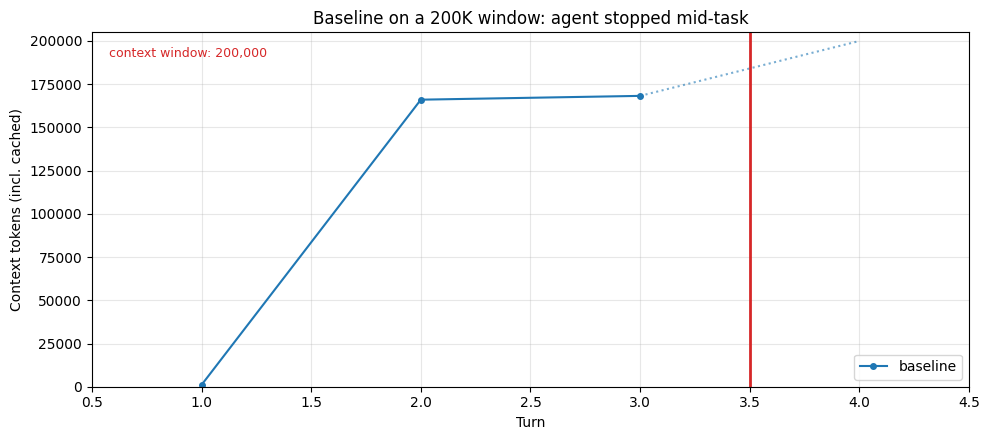

⚠ Baseline HIT THE CONTEXT WINDOW LIMIT.
  Completed 3 turns before the API rejected the next request.
  Last successful context: 168,242 tokens
  File reads attempted: 8
  Notes taken: 2

  The agent stopped mid-task. Without context management, it cannot continue past this point.


In [9]:
# No new agent run here. We reuse the Part-1 baseline's token_trajectory
# and clip it at the turn where context first exceeded 200K, to show what
# the same run would look like from a 200K model's perspective.
cross_turn = next((t for t, tok in baseline.token_trajectory if tok > 200_000), None)

if cross_turn is None:
    print(
        "Baseline never exceeded 200K tokens this run; a 200K model "
        "would have seen the same result."
    )
else:
    # Plot the turns that fit under 200K, plus a dotted segment to the
    # rejected turn and a red cutoff marker between them.
    clipped_traj = [(t, tok) for t, tok in baseline.token_trajectory if t < cross_turn]
    turns_c = [t for t, _ in clipped_traj]
    toks_c = [tok for _, tok in clipped_traj]
    rejected_ctx = dict(baseline.token_trajectory).get(cross_turn, 200_000)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(turns_c, toks_c, marker="o", markersize=4, label="baseline")
    # Dotted segment from last successful turn to the rejected turn
    ax.plot(
        [turns_c[-1], cross_turn],
        [toks_c[-1], min(rejected_ctx, 200_000)],
        linestyle=":",
        color="#1f77b4",
        alpha=0.6,
        linewidth=1.5,
    )
    # Hard red vertical line marking the cutoff between the last
    # successful turn and the rejected one
    cutoff_x = (turns_c[-1] + cross_turn) / 2
    ax.axvline(x=cutoff_x, color="#d62728", linewidth=2)
    ax.set_xlim(0.5, cross_turn + 0.5)
    ax.set_ylim(0, 205_000)
    ax.text(
        0.02,
        0.96,
        "context window: 200,000",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="#d62728",
    )
    ax.set_xlabel("Turn")
    ax.set_ylabel("Context tokens (incl. cached)")
    ax.set_title("Baseline on a 200K window: agent stopped mid-task")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    last_turn = clipped_traj[-1][0]
    last_ctx = clipped_traj[-1][1]
    reads_done = sum(1 for t, _ in baseline.file_reads if t < cross_turn)
    notes_at_stop = sum(
        1
        for m in baseline.messages[: 2 * cross_turn]
        if isinstance(m.get("content"), list)
        for b in m["content"]
        if b.get("type") == "tool_use" and b.get("name") == "record_finding"
    )
    print("⚠ Baseline HIT THE CONTEXT WINDOW LIMIT.")
    print(f"  Completed {last_turn} turns before the API rejected the next request.")
    print(f"  Last successful context: {last_ctx:,} tokens")
    print(f"  File reads attempted: {reads_done}")
    print(f"  Notes taken: {notes_at_stop}")
    print()
    print(
        "  The agent stopped mid-task. Without context management, it "
        "cannot continue past this point."
    )

Both failure modes come from the same underlying problem: the context window fills with hundreds of thousands of tokens of file content, most of it already processed and noted. What differs is how the failure surfaces. On a 200K window it's a hard stop: the API rejects the next request and the task ends mid-phase. On a 1M window the agent keeps running, but context rot sets in as the window fills: an early document read is still technically present, but by the end of the run it's buried under everything read since, and the model's ability to recall its details degrades. The agent completes, but the quality of the synthesis depends on recall that's fighting against that pile. Prefill latency scales with it too: every turn pays to process the full context, regardless of how much of it is still useful.

The primitives below each address this by keeping the working set small enough that neither failure mode bites: the window doesn't fill, so smaller models don't stop and larger models don't degrade. Plots include the dashed 200K reference line so you can see where an earlier model would have been cut off.

---

## Compaction

[Compaction](https://platform.claude.com/docs/en/build-with-claude/compaction) is a useful strategy for managing context in long-running conversations: it takes a conversation nearing the context window limit, summarizes its contents, and reinitiates with that summary. This addresses the agent's own reasoning text, user back-and-forth, and decisions made over the course of a session. The specific sequence of actions and exact wording from earlier turns won't be preserved, but the goals, decisions, and major discoveries the agent made are summarized — what the summary retains depends on your compaction prompt, which we cover below.

At its core, compaction distills the contents of a context window in a high-fidelity manner, enabling the agent to continue with minimal performance degradation. The trade-off is in choosing what the summary must retain versus what it can safely drop: overly aggressive compaction can lose subtle but critical context whose importance only becomes apparent later. The summary preserves key decisions and facts but may drop specific numbers or exact phrasing. It costs inference (the summarizer model runs), but handles all context growth, not just tool results.

### How it works under the hood

Here's a minimal sample implementation of compaction. Our first-party API provides a robust, tested version (automatic triggering at a token threshold, a typed content block that slots natively into the conversation, correct tool-use pairing), but the ~25-line version below makes the mechanism concrete: render the conversation to text, ask the model to summarize it, replace the old messages with that summary.

In [10]:
def demo_compact(client, messages: list[dict], model: str) -> list[dict]:
    """Summarize the conversation and return a fresh message list containing only the summary."""
    # Render to a plain-text transcript
    lines: list[str] = []
    for msg in messages:
        role = msg["role"]
        content = msg.get("content", "")
        if isinstance(content, str):
            lines.append(f"[{role}] {content}")
        elif isinstance(content, list):
            for block in content:
                bt = block.get("type", "?")
                if bt == "text":
                    lines.append(f"[{role}] {block['text']}")
                elif bt == "tool_use":
                    lines.append(f"[{role}→tool] {block['name']}({block.get('input', {})})")
                elif bt == "tool_result":
                    body = block.get("content", "")
                    body = body if isinstance(body, str) else json.dumps(body)
                    lines.append(f"[tool_result] {body[:200]}{'…' if len(body) > 200 else ''}")
    transcript = "\n".join(lines)

    resp = client.messages.create(
        model=model,
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": (
                    "Summarize the following agent transcript, preserving key "
                    "decisions, facts learned, and open threads. Be concise.\n\n"
                    f"<transcript>\n{transcript}\n</transcript>"
                ),
            }
        ],
    )
    summary = resp.content[0].text
    return [{"role": "user", "content": f"[conversation summary]\n{summary}"}]

In [11]:
# Demonstrate on a longer synthetic conversation so the summary is meaningfully shorter
demo_convo = []
organisms = [
    (
        "C. elegans",
        "18-day median lifespan at 20°C. Survival curve takes 4-6 weeks. Automated platforms handle thousands of animals. Genome-wide RNAi by feeding, fast CRISPR knock-ins. ~40% human orthology, no adaptive immunity, post-mitotic soma.",
    ),
    (
        "Drosophila",
        "60-80 day median lifespan at 25°C. Survival curves take 3-4 months. GAL4/UAS tissue-specific expression, FLP/FRT mosaic analysis, mature CRISPR. ~60% human disease gene orthology. Good for cardiac aging and neurodegeneration models.",
    ),
    (
        "Mouse",
        "~24-30 month median lifespan. Full study is 3-year commitment, $1-2/day/animal, $100K+ per 100-mouse cohort. Cre-lox conditionals, inbred strain panels, humanized models. ~85% orthology, best translational predictor.",
    ),
    (
        "Killifish",
        "4-6 month median lifespan (GRZ strain), shortest-lived vertebrate in the lab. Survival curves under a year. CRISPR works, toolkit still thin. ~70% orthology. Rapid vertebrate aging phenotypes on a compressed timeline.",
    ),
    (
        "Yeast",
        "Replicative lifespan ~25 divisions, ~1-2 weeks to result. Genome-wide deletion collection, trivial CRISPR, pooled competitive assays. ~30% orthology. Great for mechanism, not for translation.",
    ),
    (
        "Naked mole-rat",
        "Max lifespan >37 years, negligible senescence. No controlled genetics (eusocial breeding). Cell-line studies only. Near-zero cancer incidence. Comparative biology resource, not a screening organism.",
    ),
]
for name, facts in organisms:
    demo_convo.append({"role": "user", "content": f"Tell me about {name} for aging research."})
    demo_convo.append({"role": "assistant", "content": f"{name}: {facts}"})
demo_convo.append({"role": "user", "content": "What are the key tradeoffs across all of these?"})
demo_convo.append(
    {
        "role": "assistant",
        "content": "The core tradeoff is throughput vs. translational relevance. Short-lived invertebrates (worm, fly, yeast) let you screen fast but translate weakly. Mouse is the translational gatekeeper but slow and expensive. Killifish tries to split the difference. The mole-rat is a comparative outlier you study to understand exceptional longevity, not to screen interventions.",
    }
)

before_tokens = count_tokens(json.dumps(demo_convo))
compacted = demo_compact(client, demo_convo, MODEL)
after_tokens = count_tokens(json.dumps(compacted))
print(
    f"Conversation size: ~{before_tokens:,} → ~{after_tokens:,} tokens "
    f"({(before_tokens - after_tokens) / before_tokens:.0%} reduction)"
    if after_tokens < before_tokens
    else f"Conversation size: ~{before_tokens:,} → ~{after_tokens:,} tokens"
)
print(f"\nSummary produced:\n{compacted[0]['content'][:800]}")
if len(compacted[0]["content"]) > 800:
    print("...")

Conversation size: ~741 → ~449 tokens (39% reduction)

Summary produced:
[conversation summary]
## Summary: Model Organisms for Aging Research

### Key Facts Learned
| Organism | Lifespan | Study Duration | Human Orthology | Standout Feature |
|---|---|---|---|---|
| *C. elegans* | 18-day median | 4–6 weeks | ~40% | Genome-wide RNAi; high throughput |
| *Drosophila* | 60–80 days | 3–4 months | ~60% | Tissue-specific genetics; cardiac/neuro models |
| Mouse | 24–30 months | ~3 years | ~85% | Best translational predictor; expensive ($100K+/cohort) |
| Killifish | 4–6 months | <1 year | ~70% | Shortest-lived vertebrate; thin toolkit |
| Yeast | ~25 divisions | 1–2 weeks | ~30% | Mechanistic screening; poor translation |
| Naked mole-rat | >37 years | N/A | — | Negligible senescence; no genetic control |

### Core Tradeoff
**Throughput ↔ Translational relevance** —
...


The sample above demonstrates the mechanism: the model produces a condensed version of the conversation that the agent can continue from.

### Using the API

Our API provides this natively as the `compact_20260112` context edit. It triggers automatically at a token threshold (minimum 50K), returns a typed `compaction` content block that slots into the conversation natively, and handles tool-use pairing across the summary boundary. When compaction fires, you serialize the compaction block back (`{"type": "compaction", "content": block.content}`) and the API drops everything before it on the next request.

**API Documentation:** [Compaction — platform.claude.com](https://platform.claude.com/docs/en/build-with-claude/compaction)

Here's the research agent running with compaction configured. We set the trigger at 180K so the first batch of reads (~165K) stays under it: the compaction trajectory tracks the baseline through that batch, then diverges when the second batch pushes context past the trigger. Watch for `⊟ COMPACTION` lines in the output and the drop on the plot where the summary replaces the earlier conversation.

┌─ [compaction]
│  turn  1  ctx=  1,129
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file        /research/yeast_review.md  → ~27,320 tok
│            read_file        /research/killifish_review.md  → ~27,349 tok
│  turn  2  ctx=166,103
│            record_finding   "## BATCH 1 DETAILED NOTE: High-Throughput Model Or..."
│  turn  3  ctx=169,164
│            read_file        /research/mouse_review.md  → ~27,390 tok
│            read_file        /research/zebrafish_review.md  → ~27,363 tok
│            read_file        /research/nmr_review.md  → ~27,287 tok
│            read_file        /research/rhesus_review.md  → ~27,285 tok
│  ⊟ COMPACTION (turn 4): ~2,783-token summary replaces prior turns
│  turn  5  ctx=  5,635
│            search_files     'comparative aging model organisms synthesis pipeline translational'
│  turn  6  ctx=  5,751
│            search_files   

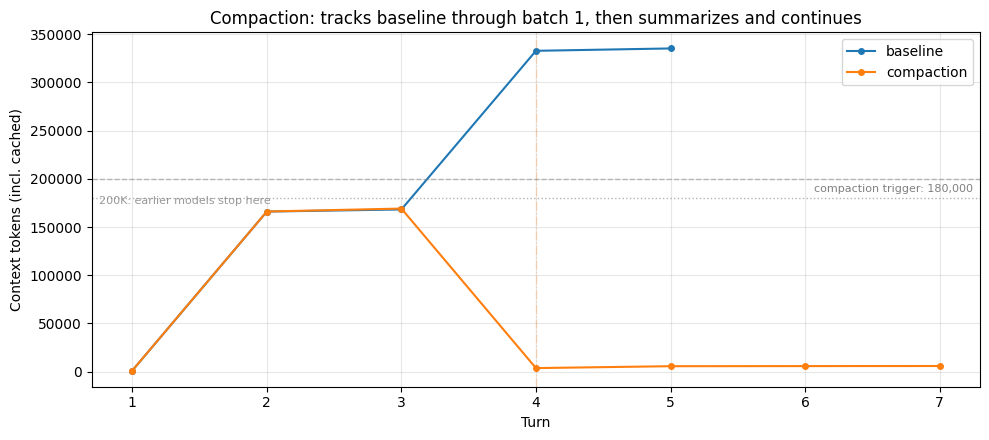

Baseline:    completed turn 5, peak 335,279 tokens
Compaction:  completed turn 7, peak 169,164 tokens, 1 compaction event(s)
  Compaction #1 at turn 4: ~2,783-token summary

→ Baseline climbed to 335,279 tokens; compaction kept the peak at 169,164. On a smaller context window the baseline would have been cut off mid-task; here it completed, but every turn paid to process the full pile.


In [13]:
COMPACTION_TRIGGER = 180_000  # above batch-1's ~165K so the rise is visible before compaction fires

compaction_run = run_research_session(
    RESEARCH_TASK,
    betas=["compact-2026-01-12"],
    context_management={
        "edits": [
            {
                "type": "compact_20260112",
                "trigger": {"type": "input_tokens", "value": COMPACTION_TRIGGER},
            }
        ]
    },
    max_turns=12,
    label="compaction",
)

plot_trajectories(
    {"baseline": baseline, "compaction": compaction_run},
    "Compaction: tracks baseline through batch 1, then summarizes and continues",
    triggers={"compaction": COMPACTION_TRIGGER},
)

compaction_events = [e for e in compaction_run.events if e["kind"] == "compaction"]

# Outcome comparison
print(
    f"Baseline:    {'HIT LIMIT at' if baseline.hit_limit else 'completed'} "
    f"turn {len(baseline.token_trajectory)}, "
    f"peak {max(t for _, t in baseline.token_trajectory):,} tokens"
)
print(
    f"Compaction:  {'HIT LIMIT at' if compaction_run.hit_limit else 'completed'} "
    f"turn {len(compaction_run.token_trajectory)}, "
    f"peak {max(t for _, t in compaction_run.token_trajectory):,} tokens, "
    f"{len(compaction_events)} compaction event(s)"
)

if compaction_events:
    for i, ev in enumerate(compaction_events, 1):
        print(
            f"  Compaction #{i} at turn {ev['turn']}: ~{count_tokens(ev['summary']):,}-token summary"
        )

baseline_peak = max(t for _, t in baseline.token_trajectory)
compaction_peak = max(t for _, t in compaction_run.token_trajectory)
print(
    f"\n→ Baseline climbed to {baseline_peak:,} tokens; compaction kept "
    f"the peak at {compaction_peak:,}. On a smaller context window the "
    f"baseline would have been cut off mid-task; here it completed, but "
    f"every turn paid to process the full pile."
)

In [14]:
# What compaction costs: check the summary text directly for a MIX of
# details. We inspect what the summary PRESERVED, not what the agent
# happens to have in context at end-of-run (which could include reads
# that happened after compaction fired).
compaction_events = [e for e in compaction_run.events if e["kind"] == "compaction"]

print("=" * 70)
print("WHAT COMPACTION COSTS: what the summary preserved vs. dropped")
print("=" * 70)

if not compaction_events:
    print("(Compaction did not fire this run; probe skipped)")
else:
    # Use the last compaction summary — it covers the most history.
    last_ev = compaction_events[-1]
    summary_text = last_ev["summary"]
    n_tok = count_tokens(summary_text)
    print(
        f"Last compaction at turn {last_ev['turn']} produced a "
        f"~{n_tok:,}-token summary. The file content read before "
        f"that point was distilled into this.\n"
    )
    print(
        "Checking the summary text directly for six details: three "
        "HIGH-LEVEL facts (central to the task, likely summarized) and "
        "three OBSCURE specifics (appendix table cells, unlikely to make "
        "the cut).\n"
    )

    results = []
    for question, answer_key, expected_survive in COMPACTION_PROBES:
        survived = answer_key.lower() in summary_text.lower()
        results.append((question, answer_key, expected_survive, survived))

    for label, expect in [
        ("HIGH-LEVEL FACTS (expected to survive)", True),
        ("OBSCURE SPECIFICS (expected to be lost)", False),
    ]:
        print(f"── {label} ──")
        for q, key, exp, surv in results:
            if exp != expect:
                continue
            status = "✓ in summary" if surv else "✗ not in summary"
            print(f"  {status:<18} looking for '{key}' — {q}")
        print()

    hl_survived = sum(1 for _, _, e, s in results if e and s)
    hl_total = sum(1 for _, _, e, _ in results if e)
    ob_survived = sum(1 for _, _, e, s in results if not e and s)
    ob_total = sum(1 for _, _, e, _ in results if not e)

    print("=" * 70)
    print(
        f"RESULT: high-level {hl_survived}/{hl_total} preserved, "
        f"obscure {ob_survived}/{ob_total} preserved"
    )
    print("=" * 70)

    # Show a representative excerpt of the summary so the reader can see
    # the compression directly.
    excerpt = summary_text.strip()
    if len(excerpt) > 600:
        excerpt = excerpt[:600] + "…"
    print("\nExcerpt from the summary (first ~600 chars):\n")
    for line in excerpt.splitlines():
        print(f"  {line}")

WHAT COMPACTION COSTS: what the summary preserved vs. dropped
Last compaction at turn 4 produced a ~2,783-token summary. The file content read before that point was distilled into this.

Checking the summary text directly for six details: three HIGH-LEVEL facts (central to the task, likely summarized) and three OBSCURE specifics (appendix table cells, unlikely to make the cut).

── HIGH-LEVEL FACTS (expected to survive) ──
  ✓ in summary       looking for '18' — What is the approximate median lifespan of C. elegans at 20°C?
  ✓ in summary       looking for 'killifish' — Which model organism is the shortest-lived vertebrate used in aging research?
  ✓ in summary       looking for '60' — Roughly what percentage of human disease genes have Drosophila orthologs?

── OBSCURE SPECIFICS (expected to be lost) ──
  ✗ not in summary   looking for '61' — In the appendix Table A5, what is the I-squared heterogeneity value for the NAD+ precursor intervention?
  ✗ not in summary   looking for '55' —

### Analysis

The baseline keeps climbing until it either hits a context-window limit (a hard stop on smaller windows) or accumulates enough tokens that context rot meaningfully degrades recall. Compaction addresses both: when context crosses the trigger, the older conversation is replaced by a model-generated summary and context drops sharply. The agent continues with a lean window instead of an ever-growing one.

The probe above checks the summary text directly for a *mix* of details. The pattern that tends to emerge: high-level facts central to the task (lifespan figures the agent noted, organism identities, major comparisons) usually survive in the summary. Obscure specifics (a single cell in an appendix table, a heterogeneity statistic) usually don't. This is a meaningful difference from tool-result clearing: clearing drops tool results *wholesale* so the content is gone until re-fetched, while compaction keeps the *substance* in compressed form but loses verbatim detail.

What compaction gets you is a general-purpose way to keep the window lean: it handles dialogue and tool results together, the important content survives in summarized form, and the agent keeps working under conditions where it would otherwise be cut off or swamped. What it doesn't get you is verbatim fidelity on specifics, or cross-session persistence. If your context bloat is mostly re-fetchable tool output, clearing is cheaper and lossless (the agent can just call the tool again). If it's dialogue and reasoning that can't be re-fetched, compaction is the right fit.

### Implementing compaction effectively

The `instructions` parameter lets you replace the default summarization prompt entirely. The [compaction docs](https://platform.claude.com/docs/en/build-with-claude/compaction#custom-summarization-instructions) give the default prompt verbatim:

> You have written a partial transcript for the initial task above. Please write a summary of the transcript. The purpose of this summary is to provide continuity so you can continue to make progress towards solving the task in a future context, where the raw history above may not be accessible and will be replaced with this summary. Write down anything that would be helpful, including the state, next steps, learnings etc. You must wrap your summary in a `<summary></summary>` block.

This helps give you a place to start. However, custom `instructions` don't supplement this prompt — they completely replace it. So if you provide your own, you're responsible for the full framing. The docs' example for a coding context is `"Focus on preserving code snippets, variable names, and technical decisions."`

For this cookbook's research agent, you might write something that names the specific details the probe above showed are at risk of being lost:

```python
context_management={
    "edits": [{
        "type": "compact_20260112",
        "trigger": {"type": "input_tokens", "value": 150_000},
        "instructions": (
            "Summarize this research agent transcript. Preserve every "
            "quantitative lifespan figure and effect size with its "
            "source organism, and note which documents have been read "
            "and which remain. Wrap the summary in <summary></summary>."
        ),
    }]
}
```

---

## Tool-Result Clearing

When an agent calls tools, each result gets appended to the conversation as a `tool_result` block ([context editing docs](https://platform.claude.com/docs/en/build-with-claude/context-editing)). Those blocks count toward the input-token budget on every subsequent turn, even after the agent has processed the content and moved on. For tools that are re-callable (file reads, API queries, search), carrying the verbatim result forward is often unnecessary; the agent can just call the tool again if it needs to.

Clearing replaces old `tool_result` blocks with a short placeholder string. The `tool_use` block that preceded it stays, so the model retains a record that it made the call (and with what input), but the bulky response body is gone. This is the cheapest of the three primitives: no inference cost, just a mechanical edit to the message list.

### How it works under the hood

To make the mechanism concrete, here's a minimal sample implementation of tool-result clearing. Our first-party API provides a robust, tested version of this (automatic triggering, correct block-pairing invariants, tool exclusions, and more), but seeing the ~15-line version makes the core operation tangible: walk the message list, find `tool_result` blocks, replace the content of all but the most recent few with a placeholder.

In [15]:
def demo_clear_tool_results(messages: list[dict], keep: int = 3) -> int:
    """Replace the content of all but the last `keep` tool_result blocks.
    Returns the number of blocks cleared."""
    positions: list[tuple[int, int]] = []
    for mi, msg in enumerate(messages):
        if msg.get("role") != "user" or not isinstance(msg.get("content"), list):
            continue
        for bi, block in enumerate(msg["content"]):
            if isinstance(block, dict) and block.get("type") == "tool_result":
                positions.append((mi, bi))

    to_clear = positions[:-keep] if keep > 0 else positions
    for mi, bi in to_clear:
        messages[mi]["content"][bi]["content"] = "[cleared to save context]"
    return len(to_clear)

In [28]:
# Demonstrate on a small message list using the actual research corpus
sample_paths = list(CORPUS.keys())[:3]  # first three docs

demo = [{"role": "user", "content": "Read three files and summarize."}]
for i, path in enumerate(sample_paths):
    demo.append(
        {
            "role": "assistant",
            "content": [
                {"type": "tool_use", "id": f"t{i}", "name": "read_file", "input": {"path": path}},
            ],
        }
    )
    demo.append(
        {
            "role": "user",
            "content": [
                {"type": "tool_result", "tool_use_id": f"t{i}", "content": CORPUS[path]},
            ],
        }
    )

before_tokens = count_tokens(json.dumps(demo))
cleared = demo_clear_tool_results(demo, keep=1)
after_tokens = count_tokens(json.dumps(demo))

print(f"Cleared {cleared} of 3 tool results (keep=1 leaves the most recent)")
print(
    f"Message-list size: ~{before_tokens:,} → ~{after_tokens:,} tokens "
    f"({(before_tokens - after_tokens) / before_tokens:.0%} reduction)"
)
print()
print("What each tool_result looks like now:")
for _i, msg in enumerate(demo):
    if not isinstance(msg.get("content"), list):
        continue
    for block in msg["content"]:
        if block.get("type") == "tool_use":
            print(f"\n  [tool_use]  read_file({block['input']['path']})")
        elif block.get("type") == "tool_result":
            body = block["content"]
            if body == "[cleared to save context]":
                print(f"  [tool_result] {body!r}  (← cleared)")
            else:
                preview = body[:80].replace("\n", " ")
                print(f"  [tool_result] {preview!r}... (~{count_tokens(body):,} tokens retained)")

Cleared 2 of 3 tool results (keep=1 leaves the most recent)
Message-list size: ~128,740 → ~43,060 tokens (67% reduction)

What each tool_result looks like now:

  [tool_use]  read_file(/research/celegans_review.md)
  [tool_result] '[cleared to save context]'  (← cleared)

  [tool_use]  read_file(/research/drosophila_review.md)
  [tool_result] '[cleared to save context]'  (← cleared)

  [tool_use]  read_file(/research/mouse_review.md)
  [tool_result] '# Model Organism Review: Mus musculus in Aging Research  The laboratory mouse is'... (~41,155 tokens retained)


The sample above shows the mechanism. What's missing from it: token counting and automatic triggering, correct `tool_use`/`tool_result` pairing invariants, tool-specific exclusions, and awareness on the model side that clearing happened.

### Using the API

Our API provides this natively as the `clear_tool_uses_20250919` context edit. It handles token counting and triggering server-side, preserves block pairing, and lets you exempt specific tools from clearing (useful when the memory tool is also active, as we'll see later). When clearing fires, the response includes `context_management.applied_edits` with details on how many tool uses were cleared and how many tokens were freed.

> There's also `clear_thinking_20251015` for extended-thinking blocks. Same config shape, different `type`. It must be the first entry in the `edits` array if you're using both.

**API Documentation:** [Context editing — platform.claude.com](https://platform.claude.com/docs/en/build-with-claude/context-editing)

Here's the research agent running with clearing enabled. The baseline's context climbed with every file read; clearing keeps this run bounded by dropping old tool results whenever context climbs past the trigger. Watch for `✂ CLEARING` lines in the output; dashed vertical lines on the plot mark each firing.

┌─ [clearing]
│  turn  1  ctx=  1,058
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file        /research/yeast_review.md  → ~27,320 tok
│            read_file        /research/killifish_review.md  → ~27,349 tok
│  turn  2  ctx=166,043
│            record_finding   "## BATCH 1 NOTES: High-Throughput Model Organisms ..."
│  turn  3  ctx=169,211
│            read_file        /research/mouse_review.md  → ~27,390 tok
│            read_file        /research/zebrafish_review.md  → ~27,363 tok
│            read_file        /research/nmr_review.md  → ~27,287 tok
│            read_file        /research/rhesus_review.md  → ~27,285 tok
│  ✂ CLEARING (turn 4): 4 tool results cleared, ~163,817 tokens freed
│  turn  4  ctx=169,174
│            record_finding   ""
│  ✂ CLEARING (turn 5): 4 tool results cleared, ~163,811 tokens freed
│  turn  5  ctx=169,255
│            record_find

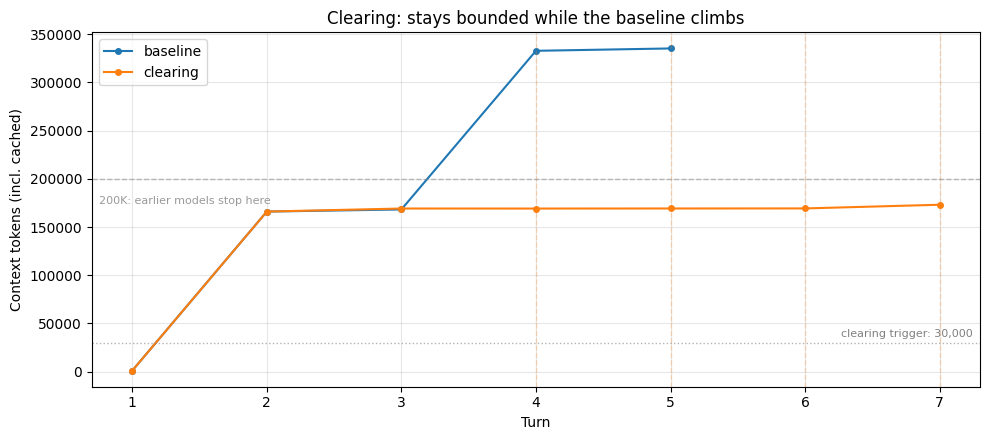

Baseline:  completed turn 5, peak 335,279 tokens
Clearing:  completed turn 7, peak 173,137 tokens

→ Baseline climbed to 335,279 tokens; clearing kept the peak at 173,137. On a smaller context window the baseline would have been cut off; here both completed, but the baseline was attending to far more on every turn.

Clearing events: 4
File reads: baseline=8, clearing=8


In [29]:
CLEARING_KEEP = 4  # How many most-recent tool results survive each clearing

clearing_run = run_research_session(
    RESEARCH_TASK,
    betas=["context-management-2025-06-27"],
    context_management={
        "edits": [
            {
                "type": "clear_tool_uses_20250919",
                "trigger": {"type": "input_tokens", "value": 30_000},
                "keep": {"type": "tool_uses", "value": CLEARING_KEEP},
                "clear_at_least": {"type": "input_tokens", "value": 10_000},
            }
        ]
    },
    label="clearing",
    max_turns=12,
)

plot_trajectories(
    {"baseline": baseline, "clearing": clearing_run},
    "Clearing: stays bounded while the baseline climbs",
    triggers={"clearing": 30_000},
)

# Show outcome comparison
baseline_turns = len(baseline.token_trajectory)
clearing_turns = len(clearing_run.token_trajectory)
print(
    f"Baseline:  {'HIT LIMIT at' if baseline.hit_limit else 'completed'} "
    f"turn {baseline_turns}, peak {max(t for _, t in baseline.token_trajectory):,} tokens"
)
print(
    f"Clearing:  {'HIT LIMIT at' if clearing_run.hit_limit else 'completed'} "
    f"turn {clearing_turns}, peak {max(t for _, t in clearing_run.token_trajectory):,} tokens"
)

baseline_peak = max(t for _, t in baseline.token_trajectory)
clearing_peak = max(t for _, t in clearing_run.token_trajectory)
print(
    f"\n→ Baseline climbed to {baseline_peak:,} tokens; clearing kept "
    f"the peak at {clearing_peak:,}. On a smaller context window the "
    f"baseline would have been cut off; here both completed, but the "
    f"baseline was attending to far more on every turn."
)

print(f"\nClearing events: {len([e for e in clearing_run.events if e['kind'] == 'clearing'])}")
print(
    f"File reads: baseline={baseline.tool_counts.get('read_file', 0)}, "
    f"clearing={clearing_run.tool_counts.get('read_file', 0)}"
)

In [30]:
# What's lost: which file reads are no longer in the clearing run's context?
print("=" * 60)
print("WHAT CLEARING COSTS: reads no longer in context")
print("=" * 60)
show_cleared_reads(clearing_run, keep=CLEARING_KEEP)
print(
    "\nThe cleared reads above are gone from the conversation. If the "
    "agent needs that content again, it must call read_file again; the "
    "information is re-fetchable, but the original read is no longer "
    "visible in context."
)

WHAT CLEARING COSTS: reads no longer in context
Total file reads across session: 8
Last clearing event fired at turn 7 (keep=4)

Reads cleared from context: 7
  ✗ turn  1: /research/celegans_review.md
  ✗ turn  1: /research/drosophila_review.md
  ✗ turn  1: /research/yeast_review.md
  ✗ turn  1: /research/killifish_review.md
  ✗ turn  3: /research/mouse_review.md
  ✗ turn  3: /research/zebrafish_review.md
  ✗ turn  3: /research/nmr_review.md

Reads still in context (within the keep=4 window or after the last clearing): 1
  ✓ turn  3: /research/rhesus_review.md

The cleared reads above are gone from the conversation. If the agent needs that content again, it must call read_file again; the information is re-fetchable, but the original read is no longer visible in context.


### Analysis

The baseline keeps climbing; the clearing run stays bounded. Once context is past the trigger (30K here) and there are more than `keep` tool uses on record, clearing fires server-side: tool results older than the most recent `keep` are replaced with placeholders and context drops back down. The dashed lines on the plot mark each firing. That bounded window means the run doesn't hit a hard limit on smaller models, and it doesn't accumulate into the range where context rot degrades recall.

The second cell above shows what this costs. Every file read except the most recent few is gone from context. When the agent reaches the synthesis phase, it has two options. It can work from its own notes plus whatever recent reads survived the last clearing: if the notes were thorough, this is fine; if they were sparse, the synthesis misses details the agent saw but didn't record. Or it can re-fetch cleared content by calling `read_file` again: the clearing run may show more file reads than the baseline for the same documents, because some reads were cleared before the agent was done with them. How much the second path costs depends on your tools: re-reading a local file is nearly free, but re-calling a rate-limited or slow API is not. Tuning `keep` and `trigger` shifts where the agent lands between these two.

What clearing gets you is a bounded window at no inference cost, avoiding both the hard-limit cutoff and the recall degradation that comes with a large accumulated context. What it doesn't get you is any help with content that isn't a tool result (the agent's own reasoning, user messages) or any persistence across sessions.

### Implementing clearing effectively

Unlike compaction and memory, clearing has no prompt to tune, and the knobs are all numeric (`trigger`, `keep`, `clear_at_least`) or list-based (`exclude_tools`). One trade-off to understand: clearing invalidates cached prompt prefixes. To account for this, clear enough tokens to make the cache invalidation worthwhile; the `clear_at_least` parameter ensures a minimum number of tokens is cleared each time. You'll incur cache write costs each time clearing fires, but subsequent requests can reuse the newly cached prefix.

The right values for `trigger` and `keep` depend on how your agent uses tool results: how large they are, how often the agent revisits them, whether re-fetching is cheap. The clearing run above used trigger=30K and keep=4; the all-three run later uses a higher trigger and keep=6 so clearing and compaction split the work. Test a few configurations against your own agent's workload: the `context_management.applied_edits` field in each response shows how many tool uses and tokens were cleared, which makes the effect of each config directly observable.

---

## Memory Tool

The [memory tool](https://platform.claude.com/docs/en/agents-and-tools/tool-use/memory-tool) enables Claude to store and retrieve information across conversations through a memory file directory. Claude can create, read, update, and delete files that persist between sessions, allowing it to build knowledge over time without keeping everything in the context window.

This is the key primitive for just-in-time context retrieval: rather than loading all relevant information upfront, agents store what they learn in memory and pull it back on demand. This keeps the active context focused on what's currently relevant, which is critical for long-running workflows where loading everything at once would overwhelm the window. Clearing and compaction both operate on the current context; neither helps when a new session starts and the window is empty. Memory solves that problem.

The memory tool operates client-side: Claude makes tool calls to perform memory operations, and your application executes those operations locally. This gives you complete control over where and how the data is stored. The API provides the tool protocol and auto-injects a system prompt establishing the memory-checking behavior; you implement the storage backend.

### How it works under the hood

Here's a minimal sample implementation: a key-value store you write to after a session and read from before the next one. Our first-party API provides the robust version (the model decides what and when to save as part of its reasoning, full file operations, auto-injected protocol prompt), but this ~10-line version makes the core pattern concrete.

In [31]:
class SimpleMemoryStore:
    def __init__(self):
        self._store: dict[str, str] = {}

    def save(self, key: str, value: str) -> None:
        self._store[key] = value

    def load(self, key: str) -> str | None:
        return self._store.get(key)

    def keys(self) -> list[str]:
        return list(self._store)


# Demonstrate the pattern manually
store = SimpleMemoryStore()
store.save(
    "lifespans",
    "C. elegans: ~18 days. Mouse: ~24-30 months. Killifish: 4-6 months (shortest vertebrate).",
)
store.save(
    "tractability",
    "Worm has genome-wide RNAi by feeding. Mouse has Cre-lox conditionals. Killifish toolkit still thin.",
)

# In "session 2", you'd inject these into the first prompt:
preamble = "\n".join(f"- {k}: {store.load(k)}" for k in store.keys())
print(f"Session-2 opening prompt would include:\n\nPrior research notes:\n{preamble}")

Session-2 opening prompt would include:

Prior research notes:
- lifespans: C. elegans: ~18 days. Mouse: ~24-30 months. Killifish: 4-6 months (shortest vertebrate).
- tractability: Worm has genome-wide RNAi by feeding. Mouse has Cre-lox conditionals. Killifish toolkit still thin.


The sample above shows the pattern, but it puts you in charge of deciding what to save and when to load it. That's exactly the work the model is better positioned to do: it knows, mid-reasoning, what facts matter and when it needs to recall them.

### Using the API

Our API provides this natively as the `memory_20250818` tool. The model decides what and when to save as part of its tool-use loop, an auto-injected system prompt establishes the protocol ("always view your memory directory before doing anything else"), and the tool offers full file operations rather than key-value. This is a client-side tool: the API provides the protocol, you implement the file backend.

**API Documentation:** [Memory tool — platform.claude.com](https://platform.claude.com/docs/en/agents-and-tools/tool-use/memory-tool)

Here's a complete handler implementing all six commands.

In [32]:
class MemoryToolHandler:
    """Client-side backend for the memory_20250818 tool.
    Implements view, create, str_replace, insert, delete, rename.
    File-backed (tempdir) so writes persist across notebook cells.
    """

    def __init__(self, base_dir: str | None = None):
        self.base = Path(base_dir or tempfile.mkdtemp(prefix="memory_"))
        self.base.mkdir(parents=True, exist_ok=True)

    def _resolve(self, path: str) -> Path:
        rel = path.removeprefix("/memories").removeprefix("/") or "."
        resolved = (self.base / rel).resolve()
        if not str(resolved).startswith(str(self.base.resolve())):
            raise ValueError(f"path escapes memory directory: {path}")
        return resolved

    def handle(self, tool_input: dict) -> str:
        cmd = tool_input.get("command")
        try:
            if cmd == "view":
                return self._view(tool_input.get("path", "/memories"))
            if cmd == "create":
                return self._create(tool_input["path"], tool_input["file_text"])
            if cmd == "str_replace":
                return self._str_replace(
                    tool_input["path"], tool_input["old_str"], tool_input["new_str"]
                )
            if cmd == "insert":
                return self._insert(
                    tool_input["path"], tool_input["insert_line"], tool_input["insert_text"]
                )
            if cmd == "delete":
                return self._delete(tool_input["path"])
            if cmd == "rename":
                return self._rename(tool_input["old_path"], tool_input["new_path"])
            return f"Error: unknown command '{cmd}'"
        except Exception as e:
            return f"Error: {e}"

    def _view(self, path: str) -> str:
        p = self._resolve(path)
        if not p.exists():
            return (
                "Directory /memories is empty."
                if path in ("/memories", "/memories/")
                else f"Error: '{path}' does not exist."
            )
        if p.is_dir():
            entries = sorted(p.iterdir())
            if not entries:
                return "(empty directory)"
            return "\n".join((f"{e.name}/" if e.is_dir() else e.name) for e in entries)
        content = p.read_text()
        lines = content.split("\n")
        return "\n".join(f"{i + 1:4d}\t{line}" for i, line in enumerate(lines))

    def _create(self, path: str, file_text: str) -> str:
        p = self._resolve(path)
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(file_text)
        return f"Created {path}"

    def _str_replace(self, path: str, old_str: str, new_str: str) -> str:
        p = self._resolve(path)
        content = p.read_text()
        if old_str not in content:
            return f"Error: old_str not found in {path}"
        if content.count(old_str) > 1:
            return f"Error: old_str appears {content.count(old_str)} times; be more specific."
        p.write_text(content.replace(old_str, new_str, 1))
        return f"Replaced in {path}"

    def _insert(self, path: str, insert_line: int, insert_text: str) -> str:
        p = self._resolve(path)
        lines = p.read_text().split("\n")
        lines.insert(insert_line, insert_text)
        p.write_text("\n".join(lines))
        return f"Inserted at line {insert_line} in {path}"

    def _delete(self, path: str) -> str:
        p = self._resolve(path)
        if p.is_dir():
            import shutil

            shutil.rmtree(p)
        else:
            p.unlink()
        return f"Deleted {path}"

    def _rename(self, old_path: str, new_path: str) -> str:
        old_p, new_p = self._resolve(old_path), self._resolve(new_path)
        new_p.parent.mkdir(parents=True, exist_ok=True)
        old_p.rename(new_p)
        return f"Renamed {old_path} → {new_path}"

> Security note: the `_resolve` method guards against path traversal (`../../etc/passwd`). In production you'd also want to cap file sizes and total directory size. See the [Memory Cookbook](https://platform.claude.com/cookbook/tool-use-memory-cookbook) for deeper memory patterns.

### Demonstrating the benefit

To see the effect concretely, we run the agent across three sessions:

1. **Session 1** does the initial research pass and writes its findings to `/memories`.
2. **Session 2 (without memory)** runs a follow-up task with an empty memory directory. It has to rediscover everything from scratch.
3. **Session 2 (with memory)** runs the same follow-up task but with access to Session 1's saved files. It reads those first and builds on them instead of re-researching.

The comparison between the two Session 2 runs is where the memory benefit becomes visible.

In [33]:
# Session 1: initial research pass, memory tool enabled
memory = MemoryToolHandler()
# Focused task for S1: read a handful of docs, save the comparative findings
S1_TASK = """Compare four model organisms for aging research: C. elegans, mouse,
killifish, and yeast. For each one, summarize lifespan, genetic tractability,
and translational relevance. Read the review documents and save your
comparative findings to /memories so a follow-up session can build on them."""

memory_s1 = run_research_session(
    S1_TASK,
    memory_handler=memory,
    max_turns=15,
    label="memory/s1",
)

print("=" * 60)
print("What Session 1 wrote to /memories:")
print("=" * 60)
for f in sorted(memory.base.iterdir()):
    content = f.read_text()
    print(f"\n▸ {f.name} (~{count_tokens(content):,} tokens)")
    for line in content.split("\n")[:10]:
        print(f"  {line}")
    if len(content.split("\n")) > 10:
        print("  ...")

┌─ [memory/s1]
│  turn  1  ctx=  1,941
│            memory           view /memories
│  turn  2  ctx=  2,025
│            search_files     'C. elegans aging lifespan'
│            search_files     'mouse aging model organism'
│            search_files     'killifish aging'
│            search_files     'yeast aging replicative chronological'
│  turn  3  ctx=  2,386
│            search_files     'aging model organism review'
│            search_files     'lifespan genetics'
│  turn  4  ctx=  2,576
│            search_files     'review'  → ~205 tok
│            search_files     'organism'  → ~205 tok
│  turn  5  ctx=  3,296
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/mouse_review.md  → ~27,390 tok
│            read_file        /research/killifish_review.md  → ~27,349 tok
│            read_file        /research/yeast_review.md  → ~27,320 tok
│  turn  6  ctx=168,218
│            memory           create /memories/aging_mod

In [34]:
# Session 2 WITHOUT memory: follow-up task with empty /memories
# This shows what happens when the agent has no prior knowledge to draw on.
S2_TASK = (
    "Write a final synthesis comparing all eight model organisms for "
    "aging research (C. elegans, Drosophila, yeast, killifish, mouse, "
    "zebrafish, naked mole-rat, rhesus), focusing on which organisms "
    "are strongest for which kinds of questions. Use information from "
    "/memories for organisms already covered there; read source "
    "documents for any organism not yet captured."
)

empty_memory = MemoryToolHandler()  # fresh, empty /memories
memory_s2_without = run_research_session(
    S2_TASK,
    memory_handler=empty_memory,
    max_turns=12,
    label="memory/s2-without",
)

┌─ [memory/s2-without]
│  turn  1  ctx=  1,952
│            memory           view /memories
│  turn  2  ctx=  2,056
│            search_files     'C. elegans aging model organism'
│            search_files     'Drosophila aging model organism'
│            search_files     'yeast aging model organism'
│            search_files     'killifish aging model organism'
│  turn  3  ctx=  2,415
│            search_files     'aging model organism lifespan'
│            search_files     'mouse aging research'
│            search_files     'naked mole-rat longevity'
│            search_files     'rhesus macaque aging'
│  turn  4  ctx=  2,755
│            search_files     'model organism'  → ~205 tok
│            search_files     'aging research review'
│            search_files     'lifespan genetics'
│  turn  5  ctx=  3,277
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file  

In [35]:
# Session 2 WITH memory: same follow-up task, but with access to Session 1's files
# The agent should read /memories first and build on it instead of re-researching.
memory_s2 = run_research_session(
    S2_TASK,
    memory_handler=memory,  # SAME handler as Session 1
    max_turns=12,
    label="memory/s2-with",
)

# Show what Session 2 read from /memories in its opening turns
print("=" * 60)
print("What Session 2 (with memory) read from /memories:")
print("=" * 60)
for msg_i, msg in enumerate(memory_s2.messages[:8]):
    # Look for memory tool calls in assistant turns
    if msg["role"] == "assistant" and isinstance(msg["content"], list):
        for block in msg["content"]:
            if block.get("type") == "tool_use" and block.get("name") == "memory":
                inp = block.get("input", {})
                print(f"\n[memory {inp.get('command', '?')}] {inp.get('path', '')}")
    # Look for the corresponding tool results (what was read)
    if msg["role"] == "user" and isinstance(msg["content"], list) and msg_i <= 6:
        for block in msg["content"]:
            if block.get("type") == "tool_result":
                result = block.get("content", "")
                if isinstance(result, str) and len(result) > 20:
                    # Show a preview of what was read
                    preview = result[:350].replace("\n", "\n  ")
                    print(f"  └ {preview}{'...' if len(result) > 350 else ''}")

┌─ [memory/s2-with]
│  turn  1  ctx=  1,952
│            memory           view /memories
│  turn  2  ctx=  2,043
│            memory           view /memories/aging_model_organisms_comparison.md  → ~2,707 tok
│  turn  3  ctx=  5,737
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file        /research/zebrafish_review.md  → ~27,363 tok
│            read_file        /research/nmr_review.md  → ~27,287 tok
│            read_file        /research/rhesus_review.md  → ~27,285 tok
│  turn  4  ctx=170,401
│            memory           str_replace /memories/aging_model_organisms_comparison.md
│  turn  5  ctx=172,415
│            record_finding   "All eight model organism reviews fully read and sy..."
│  turn  6  ctx=172,623  (final answer)
└─ completed: 6 turns, peak ctx 172,623, final ctx 172,623, 0 context event(s)

What Session 2 (with memory) read from /memories:

[memory view] /memories
  └ aging_model_organisms_comparison.md

[memory view] /mem

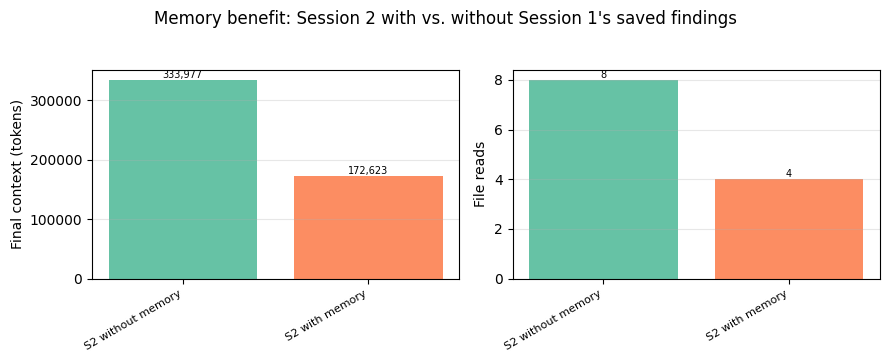

Session 2 comparison:
  Without memory: 8 file reads, 2 memory ops, peak ctx 333,977
  With memory:    4 file reads, 3 memory ops, peak ctx 172,623

→ Memory saved 4 file read(s): the agent pulled Session 1's findings from /memories instead of re-reading the source documents.

This comparison shows memory working well because Session 1's notes were comprehensive. If Session 1 had saved sparse or poorly organized notes, Session 2 would fall back to re-reading source documents. Memory's value depends on the agent's judgment about what to write.


In [36]:
# Compare: the bar chart shows final context and file reads side by side.
plot_summary_bars(
    {
        "S2 without memory": memory_s2_without,
        "S2 with memory": memory_s2,
    },
    "Memory benefit: Session 2 with vs. without Session 1's saved findings",
)

s2_with_reads = memory_s2.tool_counts.get("read_file", 0)
s2_without_reads = memory_s2_without.tool_counts.get("read_file", 0)
s2_with_mem = memory_s2.tool_counts.get("memory", 0)
s2_without_mem = memory_s2_without.tool_counts.get("memory", 0)

print("Session 2 comparison:")
print(
    f"  Without memory: {s2_without_reads} file reads, {s2_without_mem} memory ops, "
    f"peak ctx {max(t for _, t in memory_s2_without.token_trajectory):,}"
)
print(
    f"  With memory:    {s2_with_reads} file reads, {s2_with_mem} memory ops, "
    f"peak ctx {max(t for _, t in memory_s2.token_trajectory):,}"
)

if s2_with_reads < s2_without_reads:
    saved = s2_without_reads - s2_with_reads
    print(
        f"\n→ Memory saved {saved} file read(s): the agent pulled Session 1's "
        "findings from /memories instead of re-reading the source documents."
    )
elif s2_with_reads == 0 and s2_with_mem > 0:
    print(
        "\n→ Session 2 with memory completed using only /memories; "
        "no source-document re-reads needed."
    )
else:
    print(
        "\n→ Read counts are similar this run. The benefit depends on how "
        "comprehensive Session 1's notes were and how the agent chose to use them."
    )

print(
    "\nThis comparison shows memory working well because Session 1's notes "
    "were comprehensive. If Session 1 had saved sparse or poorly organized "
    "notes, Session 2 would fall back to re-reading source documents. "
    "Memory's value depends on the agent's judgment about what to write."
)

### Analysis

The comparison makes the benefit concrete. Session 2 without memory has nothing to draw on; `/memories` is empty, so it has to go back to the source documents to rediscover the same facts. Session 2 with memory opens by reading `/memories` (the auto-injected protocol makes this a default first move), finds Session 1's saved findings, and can build a synthesis from those instead of re-reading every source document.

This is just-in-time retrieval in practice: rather than loading all prior knowledge into the first prompt, the agent pulls the relevant pieces from memory on demand. The file-read counts and final context in the bar chart quantify the difference directly.

What memory gets you is cross-session persistence with lossless fidelity on whatever the agent chose to save. What it doesn't get you is any help with in-session context growth (Session 1's peak context is still high) and it adds tool-call overhead for every read and write. Memory solves the cross-session problem; clearing and compaction solve the in-session one.

### Implementing memory effectively

The `memory_20250818` tool auto-injects a system prompt establishing a check-memory-first protocol and an assume-interruption mindset ("ALWAYS VIEW YOUR MEMORY DIRECTORY BEFORE DOING ANYTHING ELSE... Your context window might be reset at any moment"). This handles the basic mechanics. Beyond that, the [memory tool docs](https://platform.claude.com/docs/en/agents-and-tools/tool-use/memory-tool#prompting-guidance) describe several ways to shape what the model saves:

**Topical guidance.** You can steer what gets written with a simple system-prompt instruction: `"Only write down information relevant to <topic> in your memory system."` For this cookbook's research agent, that might be "save comparative findings and key figures, not raw document contents."

**Keeping `/memories` organized.** If you observe the model creating cluttered memory files, try adding: `"when editing your memory folder, always try to keep its content up-to-date, coherent and organized. You can rename or delete files that are no longer relevant. Do not create new files unless necessary."` This keeps the directory from accumulating half-overlapping notes across sessions.

**Initializer-session structure.** For multi-session work, try running a dedicated first session that sets up memory artifacts before substantive work begins: a progress log, a feature checklist, references to any setup scripts. Subsequent sessions open by reading those artifacts to recover state. Pre-seeding `/memories` this way gives later sessions a consistent structure to work within instead of each session inventing its own organization.

**Storage hygiene.** On the client-side, you can also track file sizes to prevent unbounded growth, consider clearing out memory files that haven't been accessed in an extended time, and validate against path traversal.

---

## Summary: What Each Primitive Does

| Primitive | Operates on | What's traded away | Solves |
|---|---|---|---|
| **Compaction** | The whole conversation in the current window | Verbatim detail compressed into a summary; obscure specifics may be lost | All in-session growth |
| **Clearing** | Tool results in the current window | Old tool results are gone from context (must re-fetch if needed again) | Tool-result bloat |
| **Memory** | External storage, across windows | Tool-call overhead; only as good as what the agent chose to save | Cross-session persistence |

The chart below puts the three solo runs side by side, plus the baseline. Note that memory's Session 2 is a different task (follow-up synthesis) so the absolute numbers aren't directly comparable to the others; what matters for memory is the S2-with vs. S2-without comparison shown above.

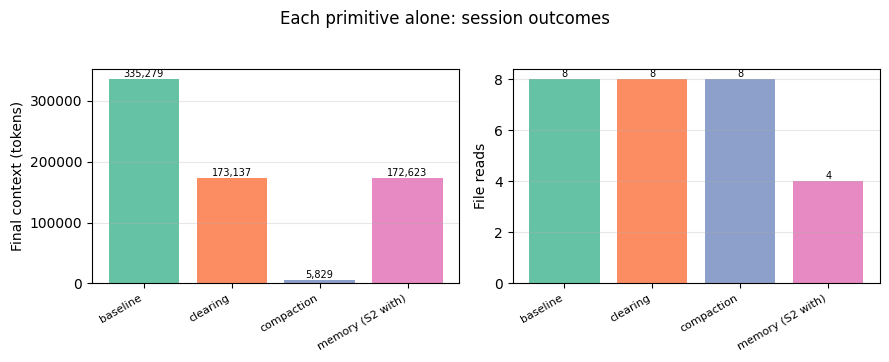

Run                  Status             Context events
------------------------------------------------------------
  baseline           completed          none
  clearing           completed          4 clearing
  compaction         completed          1 compaction
  memory (S2 with)   completed          none


In [37]:
# Side-by-side view of each primitive's solo run
solo_results = {
    "baseline": baseline,
    "clearing": clearing_run,
    "compaction": compaction_run,
    "memory (S2 with)": memory_s2,
}
plot_summary_bars(solo_results, "Each primitive alone: session outcomes")

# Completion status and events per run
print(f"{'Run':<20} {'Status':<18} {'Context events'}")
print("-" * 60)
for name, res in solo_results.items():
    status = "HIT LIMIT" if res.hit_limit else "completed"
    n_clear = sum(1 for e in res.events if e["kind"] == "clearing")
    n_compact = sum(1 for e in res.events if e["kind"] == "compaction")
    ev_parts = []
    if n_clear:
        ev_parts.append(f"{n_clear} clearing")
    if n_compact:
        ev_parts.append(f"{n_compact} compaction")
    print(f"  {name:<18} {status:<18} {', '.join(ev_parts) if ev_parts else 'none'}")

The three primitives address different slices of the context problem, which is why they compose rather than compete. Clearing and compaction manage what's inside the current window; memory moves information out of the window so it survives across sessions. Which ones you need depends on which parts of the problem your workload actually hits.

---

## Using Them Together

The three primitives target different parts of the context problem, so they can be layered. [Claude Code](https://code.claude.com/docs/en/memory) is a real-world example that employs compaction alongside [two complementary memory systems](https://code.claude.com/docs/en/memory#claudemd-vs-auto-memory): `CLAUDE.md` files hold user-defined instructions and rules (coding standards, project architecture, workflows) that the developer writes and checks into source control; auto memory holds learnings and patterns Claude writes itself (build commands, debugging insights, preferences discovered from corrections). Both are useful forms of memory for Claude Code.

The Claude Code design shows that memory can take different shapes for the same agent; one form written by the user, another written by the model. The same applies to compaction and clearing: each has configuration knobs (trigger thresholds, custom instructions, which tools to exclude) that let you tune behavior to your use case. This is why the prompting and configuration guidance in the "Implementing effectively" sections above matters: the default behavior is a starting point, but the right settings depend on what your agent actually does.

> **Note on `exclude_tools`**: when combining clearing with the memory tool, the `exclude_tools: ["memory"]` setting (shown in the config below) prevents the agent's memory reads and writes from being cleared. Without it, the agent could lose track of what it just saved. The [memory tool docs](https://platform.claude.com/docs/en/agents-and-tools/tool-use/memory-tool#using-with-context-editing) recommend this explicitly when layering the two.

Below we run the research agent with all three primitives active at once and trace what each one does over the course of the session.

> **Note on the config**: both triggers are set above the first batch's size (~167K) so the trajectory tracks the baseline through batch 1. When batch 2 pushes context to ~330K, clearing fires first (keep=6 drops the earliest reads, leaving ~210K) and compaction fires on what clearing left. Memory is active throughout. This tuning is for demonstration, so that all three primitives activate in one run. A production config depends on your agent's specific context-growth pattern.

In [38]:
# Both triggers sit above batch-1's ~167K so the rise is visible. At
# batch-2 (~330K) clearing fires first (keep=6 drops the earliest 3-4
# reads, leaving ~210K) and compaction then fires on what clearing
# left. Tuned for demo visibility, not a production recommendation.
combo_memory = MemoryToolHandler()
COMBO_CLEARING_TRIGGER = 200_000
COMBO_COMPACTION_TRIGGER = 180_000

combo_run = run_research_session(
    """Compare the model organisms in /research/ on lifespan, genetic
tractability, and translational relevance.

Work in two batches, recording a note after each batch before moving on.
Batch 1 (high-throughput): read celegans_review.md, drosophila_review.md,
yeast_review.md, killifish_review.md, then record a note. Batch 2
(low-throughput): read mouse_review.md, zebrafish_review.md,
nmr_review.md, rhesus_review.md, then record a note. Save a comparative
summary to /memories so future sessions can build on it. Finish with a
detailed synthesis.""",
    betas=["context-management-2025-06-27", "compact-2026-01-12"],
    context_management={
        "edits": [
            {
                "type": "clear_tool_uses_20250919",
                "trigger": {"type": "input_tokens", "value": COMBO_CLEARING_TRIGGER},
                "keep": {"type": "tool_uses", "value": 6},
                "clear_at_least": {"type": "input_tokens", "value": 30_000},
                "exclude_tools": ["memory"],
            },
            {
                "type": "compact_20260112",
                "trigger": {"type": "input_tokens", "value": COMBO_COMPACTION_TRIGGER},
            },
        ],
    },
    memory_handler=combo_memory,
    max_turns=20,
    label="all-three",
)

┌─ [all-three]
│  turn  1  ctx=  2,106
│            memory           view /memories
│  turn  2  ctx=  2,206
│            read_file        /research/celegans_review.md  → ~27,465 tok
│            read_file        /research/drosophila_review.md  → ~27,435 tok
│            read_file        /research/yeast_review.md  → ~27,320 tok
│            read_file        /research/killifish_review.md  → ~27,349 tok
│  turn  3  ctx=167,185
│            memory           create /memories/batch1_notes.md
│  turn  4  ctx=169,938
│            read_file        /research/mouse_review.md  → ~27,390 tok
│            read_file        /research/zebrafish_review.md  → ~27,363 tok
│            read_file        /research/nmr_review.md  → ~27,287 tok
│            read_file        /research/rhesus_review.md  → ~27,285 tok
│  ✂ CLEARING (turn 5): 2 tool results cleared, ~81,993 tokens freed
│  ⊟ COMPACTION (turn 5): ~2,839-token summary replaces prior turns
│  ✂ CLEARING (turn 6): 2 tool results cleared, ~81,810 token

In [39]:
# Build a timeline showing when each primitive activated over the session
print("=" * 70)
print("SESSION TIMELINE: all three primitives active")
print("=" * 70)

# Build turn-indexed event markers
clear_turns = {e["turn"] for e in combo_run.events if e["kind"] == "clearing"}
compact_turns = {e["turn"] for e in combo_run.events if e["kind"] == "compaction"}

# Find per-turn memory tool calls by walking messages
mem_call_turns = set()
turn = 0
for msg in combo_run.messages:
    if msg["role"] == "assistant" and isinstance(msg["content"], list):
        turn += 1
        for block in msg["content"]:
            if block.get("type") == "tool_use" and block.get("name") == "memory":
                mem_call_turns.add(turn)

# Print turn-by-turn with markers
for t, ctx in combo_run.token_trajectory:
    markers = []
    if t in clear_turns:
        markers.append("✂ CLEARING")
    if t in compact_turns:
        markers.append("⊟ COMPACTION")
    if t in mem_call_turns:
        markers.append("◇ memory")
    marker_str = "  " + "  ".join(markers) if markers else ""
    print(f"  turn {t:2d}  ctx={ctx:>7,}{marker_str}")

# Summary of what each primitive did
n_clearing = len(clear_turns)
n_compaction = len(compact_turns)
n_memory_calls = combo_run.tool_counts.get("memory", 0)
mem_files = sorted(combo_memory.base.iterdir())

print("\n" + "─" * 70)
print("What each primitive did this session:")
print(f"\n  ✂ Tool-result clearing fired {n_clearing} time(s)")
print(
    f"    → Dropped old tool results to keep context capped at ~{max(t for _, t in combo_run.token_trajectory):,} tokens"
)
print(
    f"    → {combo_run.tool_counts.get('read_file', 0)} file reads total "
    f"(vs baseline's {baseline.tool_counts.get('read_file', 0)}); some were re-fetches after context was reset"
)

if n_compaction > 0:
    print(f"\n  ⊟ Compaction fired {n_compaction} time(s)")
    for ev in combo_run.events:
        if ev["kind"] == "compaction":
            print(
                f"    → At turn {ev['turn']}: replaced prior conversation with ~{count_tokens(ev['summary']):,}-token summary"
            )
else:
    print(
        f"\n  ⊟ Compaction did not fire (clearing kept context below the {COMBO_COMPACTION_TRIGGER:,} trigger)"
    )

print(
    f"\n  ◇ Memory tool called {n_memory_calls} time(s), wrote {len(mem_files)} file(s) to /memories"
)
for f in mem_files:
    content = f.read_text()
    print(f"    → {f.name} (~{count_tokens(content):,} tokens)")
    lines = content.split("\n")
    for line in lines[:6]:
        print(f"        {line}")
    if len(lines) > 6:
        print("        ...")

print("\n" + "─" * 70)
print(
    f"Peak context: {max(t for _, t in combo_run.token_trajectory):,} tokens "
    f"(vs baseline's {max(t for _, t in baseline.token_trajectory):,})"
)
print(f"Final context: {combo_run.token_trajectory[-1][1]:,} tokens")
print(
    f"Session {'completed' if not combo_run.hit_limit else 'HIT LIMIT'} "
    f"in {len(combo_run.token_trajectory)} turns"
)

SESSION TIMELINE: all three primitives active
  turn  1  ctx=  2,106  ◇ memory
  turn  2  ctx=  2,206
  turn  3  ctx=167,185  ◇ memory
  turn  4  ctx=169,938
  turn  5  ctx=  4,798  ✂ CLEARING  ⊟ COMPACTION  ◇ memory
  turn  6  ctx=  4,901  ✂ CLEARING  ◇ memory
  turn  7  ctx=  8,121  ✂ CLEARING  ◇ memory
  turn  8  ctx= 10,524  ✂ CLEARING  ◇ memory
  turn  9  ctx= 12,799  ✂ CLEARING
  turn 10  ctx= 13,096  ✂ CLEARING
  turn 11  ctx= 13,290  ✂ CLEARING
  turn 12  ctx= 13,461  ✂ CLEARING  ◇ memory
  turn 13  ctx= 13,749  ✂ CLEARING

──────────────────────────────────────────────────────────────────────
What each primitive did this session:

  ✂ Tool-result clearing fired 9 time(s)
    → Dropped old tool results to keep context capped at ~169,938 tokens
    → 8 file reads total (vs baseline's 8); some were re-fetches after context was reset

  ⊟ Compaction fired 1 time(s)
    → At turn 5: replaced prior conversation with ~2,839-token summary

  ◇ Memory tool called 7 time(s), wrote 3 fil

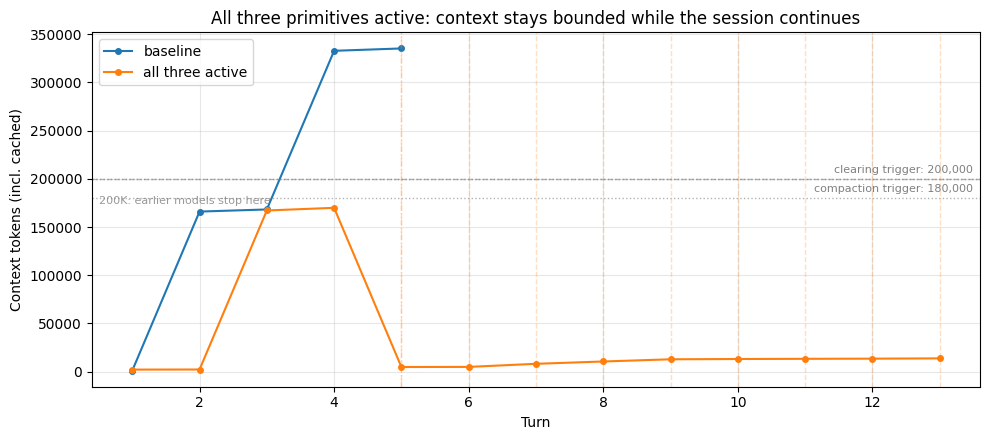

In [40]:
plot_trajectories(
    {"baseline": baseline, "all three active": combo_run},
    "All three primitives active: context stays bounded while the session continues",
    triggers={"clearing": COMBO_CLEARING_TRIGGER, "compaction": COMBO_COMPACTION_TRIGGER},
)

### What the timeline shows

With all three primitives active, each one activated for its own reason during the session. The trajectory tracked the baseline through batch 1: both triggers sit above the first batch's size, so neither edit fired until batch 2 pushed context past ~330K. At that point clearing dropped the earliest reads and compaction summarized what remained, letting the agent continue. Memory was active throughout, with the agent checking `/memories` at the start and saving its comparative notes for future sessions. The timeline above shows all three cooperating across one session.

Getting the primitives to split the work usefully takes some tuning; plan to experiment with the values against your own workload.

The point isn't that running all three produces the "best" numbers; it's that they each handle a different part of the problem when that problem actually arises. The useful question isn't "should I use all three?" but "which of the three problems does my workload actually have?"

### When you might NOT want a primitive

Not every workload needs every tool. A few cases where you'd deliberately leave one out:

- **Skip memory** if you want each session to start fresh. A user-facing chatbot where every conversation should be independent doesn't need cross-session persistence; adding memory would carry state you don't want.
- **Skip compaction** if your sessions are short enough to stay under the context limit naturally. Compaction is lossy (specific details get summarized away), so if you don't need the headroom, you're paying fidelity for nothing.
- **Skip clearing** if the agent genuinely needs to see past tool results in full. An agent doing cross-document analysis where it compares passages side by side can't re-fetch its way back to a cleared result fast enough; clearing would force redundant reads.

---

## Takeaways and Next Steps

### Lessons from the experiments

Running the research agent under these different configurations surfaces a few practical lessons:

**The shape of the trajectory reflects what each tool does.** When clearing fires you see a step-down on the turn where old tool results were removed; in longer sessions this can repeat as context climbs back over the trigger. Compaction produces a larger drop each time it fires, since the summary replaces an entire run of turns rather than just the tool results within them. The plots in this cookbook are meant to make those effects visible, so you can see concretely what changes when you turn a knob. Which tool fits your workload is a separate question, driven by what the agent needs to do.

**Lossiness is a spectrum, not a binary.** Clearing is lossless as long as the tool is re-callable. Compaction is lossy in a controlled way: the summarizer prompt (default or custom) determines what survives. Memory is lossless on what gets saved but is only as good as the agent's judgment about what to save. Each primitive trades fidelity differently.

**Layering adds capability and complexity in equal measure.** Using all three together covers more of the context problem, but also means more knobs to tune and more interactions to trace. The useful question before adding a primitive is what specific problem in your workload it solves.

**On larger context windows.** With Sonnet 4.6 and Opus 4.6 providing 1M-token context, that headroom is useful: more verbatim detail can stay around, and lossy operations can be spaced out. But as the baseline's context breakdown showed, the working set on a 1M model fills with stale tool results just as fast as on a 200K model; the difference is where the hard limit sits, not how quickly context accumulates. Context rot and prefill latency scale with how much is in the window, not with the window's limit, so keeping the working set lean is still worth doing even when the hard wall is far away.

### Thinking about your workload

This table sketches workload characteristics and which primitive is worth trying first. Treat these as hypotheses to test on your own agent, not as answers. Every workload has quirks a table can't capture.

| If your workload has... | Worth trying first | Watch for |
|---|---|---|
| Sessions spanning days or weeks | Memory tool | Tool-call overhead; stale memory if facts change |
| An agent that should learn user preferences across sessions | Memory tool | PII/sensitive data policy; stale preferences if the user changes their mind |
| Large, re-fetchable tool results | Clearing | Agent re-reading what was just cleared; tune `keep` and trigger |
| Dialogue as the primary context | Compaction | Specific figures getting summarized away |
| Tool results that aren't easily re-fetchable (ephemeral APIs, uploads) | Compaction over clearing | Summary fidelity on those specific results |
| Every session should start fresh | Skip memory | Cross-session state you don't want |
| Sessions stay well under the window | Skip compaction | Lossiness you don't need |

### What this cookbook didn't cover

**Tuning beyond the basics.** The "Implementing effectively" sections above give you a starting point for each primitive. The next step is experimentation: different use cases will get different value out of the same primitive depending on parameters and prompts. A coding agent and a research agent might both use compaction, but the `instructions` string that works for one won't work for the other; the same is true of clearing thresholds and what you guide the model to write to `/memories`.

Setting up a test harness helps here. For a simple example, the agent loop in this cookbook (`run_research_session`) returns `token_trajectory`, `events`, and `tool_counts`: you can run your agent under a handful of configs, plot the trajectories side by side, and measure what matters to you (task quality, latency, token spend).

**Adjacent features.** [Programmatic tool calling (PTC)](https://www.anthropic.com/engineering/advanced-tool-use) prevents large results from entering context at all by running tools inside a model-authored program, which is a different approach to the tool-bloat problem. [Tool search](https://www.anthropic.com/engineering/advanced-tool-use) trims tool-definition bloat when you have many tools.

### Related reading

The [Memory Cookbook](https://platform.claude.com/cookbook/tool-use-memory-cookbook) goes deeper on memory patterns with a code-review agent, and the [Compaction Cookbook](https://platform.claude.com/cookbook/tool-use-automatic-context-compaction) covers compaction in isolation. For a detailed case study of context management techniques in a multi-session software agent, see [Effective harnesses for long-running agents](https://www.anthropic.com/engineering/effective-harnesses-for-long-running-agents).

## Conclusion

This notebook walked through three context-management primitives for long-running agents: compaction to compress conversational history, tool-result clearing to drop re-fetchable tool output, and the memory tool to persist knowledge across sessions. Each addresses a different slice of the context problem.

Which primitives matter for your agent depends on where its context growth actually comes from. The configs and agent loop in this cookbook are a starting point for running your own workload under different configurations and seeing what changes.